# Fashion Product Visual Search and Recognition

This notebook is a course project for **Product Visual Search and Recognition**. It simulates a platform-style visual search workflow: first train a CNN fashion product classifier, then reuse the learned representation as image embeddings, and finally retrieve visually similar products with Top-K nearest-neighbor search.

Dataset: **Fashion Product Images Small from Kaggle**  
Dataset link: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small

By default, this notebook does **not** automatically download the dataset. Please manually download it from Kaggle, or use the Kaggle CLI if it is already configured, and extract the files under `data/raw/`.


# 0. Colab Setup and Notebook-Native ViT Pipeline

This notebook can be used in two modes: local execution and Google Colab execution. The core report pipeline already lives in notebook cells. The supervised ViT-B/16 workflow that previously called standalone Python files is now folded back into notebook functions, so this notebook can train, evaluate, build the gallery index, and evaluate retrieval without calling external project scripts.

For Colab, upload this notebook and the dataset zip `products10k.zip` to Google Drive under `MyDrive/product_visual_search/`. The setup cells mount Drive, unzip the dataset to Colab local disk, and link it into `data/raw/` so the same relative paths work locally and in the cloud.

In [1]:
from pathlib import Path
import os
import sys
import shutil
import subprocess
import zipfile

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
else:
    print("Local environment detected. Google Drive mount is skipped.")

IN_COLAB = False
Local environment detected. Google Drive mount is skipped.


In [2]:
DRIVE_ROOT = Path("/content/drive/MyDrive/product_visual_search")
PROJECT_ZIP = DRIVE_ROOT / "project.zip"
DATA_ZIP = DRIVE_ROOT / "products10k.zip"
PROJECT_DIR = Path("/content/product_visual_search")
DATA_DIR = Path("/content/data/products10k")
DRIVE_OUTPUT_DIR = DRIVE_ROOT / "outputs"

if IN_COLAB:
    print("Colab path configuration:")
    print(f"DRIVE_ROOT      = {DRIVE_ROOT}")
    print(f"PROJECT_ZIP     = {PROJECT_ZIP}")
    print(f"DATA_ZIP        = {DATA_ZIP}")
    print(f"PROJECT_DIR     = {PROJECT_DIR}")
    print(f"DATA_DIR        = {DATA_DIR}")
    print(f"DRIVE_OUTPUT_DIR= {DRIVE_OUTPUT_DIR}")
else:
    PROJECT_DIR = Path.cwd()
    print("Local project directory: current working directory")

Local project directory: current working directory


In [3]:
if IN_COLAB:
    PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(PROJECT_DIR)
    print("Notebook-native Colab mode: no project source zip is required.")
    print(f"Current working directory: {Path.cwd()}")
else:
    print("Local run: project unzip is skipped.")
    print("Current working directory: current notebook folder")

Local run: project unzip is skipped.
Current working directory: current notebook folder


In [4]:
if IN_COLAB:
    requirements_path = PROJECT_DIR / "requirements.txt"
    if requirements_path.exists():
        print(f"Installing dependencies from {requirements_path} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_path)])
    else:
        print("WARNING: requirements.txt was not found. Install missing packages manually if a later import fails.")
else:
    print("Local run: dependency installation is not forced by this notebook section.")

Local run: dependency installation is not forced by this notebook section.


In [5]:
try:
    import torch
    print(f"torch.__version__ = {torch.__version__}")
    print(f"torch.cuda.is_available() = {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU = {torch.cuda.get_device_name(0)}")
except ImportError:
    print("WARNING: PyTorch is not installed in this environment.")

torch.__version__ = 2.11.0+cu126
torch.cuda.is_available() = True
GPU = NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
def _find_dataset_component(root: Path, name: str, is_dir: bool):
    if not root.exists():
        return None
    direct = root / name
    if direct.exists() and direct.is_dir() == is_dir:
        return direct
    matches = [p for p in root.rglob(name) if p.is_dir() == is_dir]
    return matches[0] if matches else None

if IN_COLAB:
    if DATA_DIR.exists():
        print(f"Dataset directory already exists, skipping unzip: {DATA_DIR}")
    elif DATA_ZIP.exists():
        DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
        print(f"Unzipping dataset from {DATA_ZIP} to {DATA_DIR.parent} ...")
        with zipfile.ZipFile(DATA_ZIP, "r") as zf:
            zf.extractall(DATA_DIR.parent)
        if not DATA_DIR.exists():
            if _find_dataset_component(DATA_DIR.parent, "images", is_dir=True) is not None and _find_dataset_component(DATA_DIR.parent, "styles.csv", is_dir=False) is not None:
                DATA_DIR = DATA_DIR.parent
                print(f"Detected dataset files directly under: {DATA_DIR}")
            else:
                candidates = [p for p in DATA_DIR.parent.iterdir() if p.is_dir() and _find_dataset_component(p, "images", True) is not None]
                if candidates:
                    DATA_DIR = candidates[0]
                    print(f"Detected dataset directory: {DATA_DIR}")
                else:
                    print("Dataset zip extracted. If the folder name differs from products10k, update DATA_DIR if needed.")
    else:
        print(f"WARNING: DATA_ZIP was not found: {DATA_ZIP}")
        print("Please upload products10k.zip to Google Drive under MyDrive/product_visual_search/.")

    # The project scripts expect data/raw/images and data/raw/styles.csv.
    # We create lightweight symlinks from the local /content dataset copy instead of reading images directly from Drive.
    if DATA_DIR.exists() and PROJECT_DIR.exists():
        project_raw = PROJECT_DIR / "data" / "raw"
        project_raw.mkdir(parents=True, exist_ok=True)
        images_dir = _find_dataset_component(DATA_DIR, "images", is_dir=True)
        styles_csv = _find_dataset_component(DATA_DIR, "styles.csv", is_dir=False)

        if images_dir is not None:
            target_images = project_raw / "images"
            if not target_images.exists():
                try:
                    target_images.symlink_to(images_dir, target_is_directory=True)
                    print(f"Linked images: {target_images} -> {images_dir}")
                except OSError:
                    print("WARNING: Could not create images symlink. Consider copying images into data/raw/images manually.")
            else:
                print(f"Project image folder already exists: {target_images}")
        else:
            print("WARNING: Could not find an images/ folder inside DATA_DIR.")

        if styles_csv is not None:
            target_styles = project_raw / "styles.csv"
            if not target_styles.exists():
                try:
                    target_styles.symlink_to(styles_csv)
                    print(f"Linked metadata: {target_styles} -> {styles_csv}")
                except OSError:
                    shutil.copy2(styles_csv, target_styles)
                    print(f"Copied metadata: {target_styles}")
            else:
                print(f"Project metadata already exists: {target_styles}")
        else:
            print("WARNING: Could not find styles.csv inside DATA_DIR.")
else:
    print("Local run: dataset unzip is skipped. Use the local data/raw/images and data/raw/styles.csv layout.")

Local run: dataset unzip is skipped. Use the local data/raw/images and data/raw/styles.csv layout.


## Inline Supervised ViT-B/16 Pipeline

The following cell contains the former ViT training, classification evaluation, gallery-index building, and retrieval-evaluation workflow as notebook-native functions. The runner cell after it uses explicit switches so a normal Run All does not accidentally start a long GPU job.

In [7]:
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

PROJECT_ROOT = Path.cwd()
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
CANONICAL_IMAGE_DIR = DATA_RAW_DIR / "images"
STYLES_CSV = DATA_RAW_DIR / "styles.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
SPLIT_DIR = OUTPUT_DIR / "splits"
INDEX_DIR = OUTPUT_DIR / "indexes"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FULL_SPLIT_CSV = SPLIT_DIR / "full_dataset_split.csv"
FULL_CLASS_MAPPING_JSON = SPLIT_DIR / "full_class_mapping.json"
VIT_SUPERVISED_LAST_CHECKPOINT = CHECKPOINT_DIR / "vit_b16_supervised_last.pth"
VIT_SUPERVISED_BEST_CHECKPOINT = CHECKPOINT_DIR / "vit_b16_supervised_best.pth"
VIT_SUPERVISED_INDEX_PATH = INDEX_DIR / "vit_supervised_gallery_index.npz"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def to_project_relative(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_project_path(path):
    path = Path(path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def prepare_full_dataset_split(skip_image_verify=True, seed=42):
    if not CANONICAL_IMAGE_DIR.exists():
        raise FileNotFoundError(f"Missing image directory: {CANONICAL_IMAGE_DIR}")
    if not STYLES_CSV.exists():
        raise FileNotFoundError(f"Missing styles metadata: {STYLES_CSV}")
    SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

    styles = pd.read_csv(STYLES_CSV, on_bad_lines="skip")
    styles = styles[["id", "articleType"]].dropna(subset=["id", "articleType"]).copy()
    styles["image_id"] = styles["id"].astype(str)
    styles["articleType"] = styles["articleType"].astype(str)
    image_map = {
        p.stem: p
        for p in CANONICAL_IMAGE_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    }

    rows = []
    for row in styles.itertuples(index=False):
        image_path = image_map.get(row.image_id)
        if image_path is None:
            continue
        if not skip_image_verify:
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                continue
        rows.append({"image_id": row.image_id, "image_path": to_project_relative(image_path), "articleType": row.articleType})

    df = pd.DataFrame(rows)
    counts = df["articleType"].value_counts()
    df = df[df["articleType"].isin(counts[counts >= 3].index)].reset_index(drop=True)
    class_names = sorted(df["articleType"].unique())
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    df["class_id"] = df["articleType"].map(class_to_idx).astype(int)

    rng = np.random.default_rng(seed)
    split_series = pd.Series(index=df.index, dtype="object")
    for _, group in df.groupby("articleType"):
        indices = group.index.to_list()
        rng.shuffle(indices)
        n = len(indices)
        n_train = max(1, int(round(n * 0.70)))
        n_val = max(1, int(round(n * 0.15)))
        if n_train + n_val >= n:
            n_train = max(1, n - 2)
            n_val = 1
        assignments = ["train"] * n_train + ["val"] * n_val + ["test"] * (n - n_train - n_val)
        for idx, split in zip(indices, assignments):
            split_series.loc[idx] = split
    df["split"] = split_series

    df[["image_id", "image_path", "articleType", "class_id", "split"]].to_csv(FULL_SPLIT_CSV, index=False)
    FULL_CLASS_MAPPING_JSON.write_text(json.dumps({
        "class_to_idx": class_to_idx,
        "idx_to_class": {str(v): k for k, v in class_to_idx.items()},
        "num_classes": len(class_names),
        "label_name": "articleType",
    }, indent=2), encoding="utf-8")
    return df


def load_full_split_dataframe():
    if not FULL_SPLIT_CSV.exists() or not FULL_CLASS_MAPPING_JSON.exists():
        return prepare_full_dataset_split()
    split_df = pd.read_csv(FULL_SPLIT_CSV)
    missing_paths = ~split_df["image_path"].map(lambda p: resolve_project_path(p).exists())
    if missing_paths.any():
        image_map = {
            p.stem: p
            for p in CANONICAL_IMAGE_DIR.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        }
        relocated = split_df.loc[missing_paths, "image_id"].astype(str).map(image_map)
        found = relocated.notna()
        split_df.loc[relocated[found].index, "image_path"] = relocated[found].map(to_project_relative)
    split_df["image_path"] = split_df["image_path"].map(lambda p: to_project_relative(resolve_project_path(p)))
    return split_df


def get_vit_transform(image_size=224, train=False):
    ops = [transforms.Resize((image_size, image_size))]
    if train:
        ops += [transforms.RandomHorizontalFlip(p=0.5), transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10)]
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)


class VitProductDataset(Dataset):
    def __init__(self, df, transform, return_meta=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(resolve_project_path(row["image_path"])).convert("RGB")
        image = self.transform(image)
        label = int(row["class_id"])
        if self.return_meta:
            return image, label, str(row["image_id"]), str(row["image_path"]), str(row["articleType"]), str(row["split"])
        return image, label


def build_vit_b16(num_classes, pretrained=True, strict_pretrained=False):
    weights = models.ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
    try:
        model = models.vit_b_16(weights=weights)
    except Exception as exc:
        if strict_pretrained:
            raise
        print(f"warning=vit_pretrained_init_failed_falling_back_to_random reason={exc}")
        model = models.vit_b_16(weights=None)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model


def extract_vit_features(model, images):
    x = model._process_input(images)
    batch_class_token = model.class_token.expand(x.shape[0], -1, -1)
    x = torch.cat([batch_class_token, x], dim=1)
    x = model.encoder(x)
    return x[:, 0]


def topk_accuracy_count(logits, labels, k):
    k = min(k, logits.shape[1])
    preds = logits.topk(k, dim=1).indices
    return preds.eq(labels.view(-1, 1)).any(dim=1).float().sum().item()


def run_vit_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = total_samples = top1_hits = top5_hits = 0.0
    amp_enabled = scaler is not None and DEVICE.type == "cuda"
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type="cuda", enabled=amp_enabled):
                logits = model(images)
                loss = criterion(logits, labels)
            if is_train:
                if amp_enabled:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        top1_hits += topk_accuracy_count(logits.detach(), labels, 1)
        top5_hits += topk_accuracy_count(logits.detach(), labels, 5)
    return {"loss": total_loss / max(total_samples, 1), "top1": top1_hits / max(total_samples, 1), "top5": top5_hits / max(total_samples, 1), "samples": int(total_samples)}


def train_vit_supervised(epochs=3, batch_size=16, num_workers=0, lr=3e-5, weight_decay=1e-4, image_size=224, debug=False, no_pretrained=False, strict_pretrained=False):
    split_df = load_full_split_dataframe()
    mapping = json.loads(FULL_CLASS_MAPPING_JSON.read_text(encoding="utf-8"))
    train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
    val_df = split_df[split_df["split"] == "val"].reset_index(drop=True)
    if debug:
        train_df = train_df.head(100)
        val_df = val_df.head(50)
        epochs = min(epochs, 1)
    train_loader = DataLoader(VitProductDataset(train_df, get_vit_transform(image_size, train=True)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(VitProductDataset(val_df, get_vit_transform(image_size)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    model = build_vit_b16(int(mapping["num_classes"]), pretrained=not no_pretrained, strict_pretrained=strict_pretrained).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
    best_val_top1 = -1.0
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    log_rows = []
    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        train_metrics = run_vit_epoch(model, train_loader, criterion, optimizer, scaler)
        val_metrics = run_vit_epoch(model, val_loader, criterion)
        is_best = val_metrics["top1"] > best_val_top1
        best_val_top1 = max(best_val_top1, val_metrics["top1"])
        ckpt = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_top1": best_val_top1,
            "best_val_top5": val_metrics["top5"],
            "class_to_idx": mapping["class_to_idx"],
            "idx_to_class": mapping["idx_to_class"],
            "num_classes": mapping["num_classes"],
            "image_size": image_size,
            "model_name": "vit_b16_supervised",
            "architecture": "Vision Transformer ViT-B/16",
            "embedding_type": "CLS token",
            "is_smoke_test": bool(debug),
            "train_config": {"split_csv": to_project_relative(FULL_SPLIT_CSV), "epochs": epochs, "batch_size": batch_size, "is_smoke_test": bool(debug)},
        }
        torch.save(ckpt, VIT_SUPERVISED_LAST_CHECKPOINT)
        if is_best:
            torch.save(ckpt, VIT_SUPERVISED_BEST_CHECKPOINT)
        row = {"epoch": epoch, "train_loss": train_metrics["loss"], "val_loss": val_metrics["loss"], "val_top1": val_metrics["top1"], "val_top5": val_metrics["top5"], "epoch_time_seconds": time.perf_counter() - start, "is_smoke_test": bool(debug)}
        log_rows.append(row)
        print(row)
    pd.DataFrame(log_rows).to_csv(REPORT_DIR / ("vit_supervised_training_log_smoke.csv" if debug else "vit_supervised_training_log.csv"), index=False)
    return to_project_relative(VIT_SUPERVISED_BEST_CHECKPOINT)


def load_vit_supervised_model(checkpoint_path=VIT_SUPERVISED_BEST_CHECKPOINT):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model = build_vit_b16(int(ckpt["num_classes"]), pretrained=False).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, get_vit_transform(int(ckpt.get("image_size", 224))), ckpt


def evaluate_vit_supervised(batch_size=16, num_workers=0, max_samples=None):
    model, transform, ckpt = load_vit_supervised_model()
    split_df = load_full_split_dataframe()
    eval_df = split_df[split_df["split"] == "test"].reset_index(drop=True)
    if max_samples is not None:
        eval_df = eval_df.head(max_samples)
    loader = DataLoader(VitProductDataset(eval_df, transform), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    criterion = nn.CrossEntropyLoss()
    total_loss = total = top1 = top5 = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            batch_size_i = labels.size(0)
            total += batch_size_i
            total_loss += loss.item() * batch_size_i
            top1 += topk_accuracy_count(logits, labels, 1)
            top5 += topk_accuracy_count(logits, labels, 5)
    metrics = {
        "split": "test",
        "loss": total_loss / max(total, 1),
        "top1_acc": top1 / max(total, 1),
        "top5_acc": top5 / max(total, 1),
        "eval_size": int(len(eval_df)),
        "train_size": int((split_df["split"] == "train").sum()),
        "val_size": int((split_df["split"] == "val").sum()),
        "test_size": int((split_df["split"] == "test").sum()),
        "num_classes": int(ckpt["num_classes"]),
        "embedding_dim": 768,
        "checkpoint": to_project_relative(VIT_SUPERVISED_BEST_CHECKPOINT),
        "is_smoke_test": bool(ckpt.get("is_smoke_test") or max_samples),
    }
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    metrics_path = REPORT_DIR / ("vit_supervised_classification_metrics_smoke.json" if metrics["is_smoke_test"] else "vit_supervised_classification_metrics.json")
    metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    return metrics


def build_vit_supervised_index(batch_size=16, num_workers=0, max_images=None):
    model, transform, ckpt = load_vit_supervised_model()
    split_df = load_full_split_dataframe()
    gallery_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
    if max_images is not None:
        gallery_df = gallery_df.head(max_images)
    loader = DataLoader(VitProductDataset(gallery_df, transform, return_meta=True), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    embeddings, labels, image_ids, image_paths, article_types, splits = [], [], [], [], [], []
    with torch.no_grad():
        for images, batch_labels, batch_ids, batch_paths, batch_types, batch_splits in loader:
            features = extract_vit_features(model, images.to(DEVICE))
            features = torch.nn.functional.normalize(features, p=2, dim=1)
            embeddings.append(features.cpu().numpy())
            labels.extend(batch_labels.numpy().tolist())
            image_ids.extend(batch_ids)
            image_paths.extend(batch_paths)
            article_types.extend(batch_types)
            splits.extend(batch_splits)
    emb = np.vstack(embeddings).astype(np.float32)
    INDEX_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        VIT_SUPERVISED_INDEX_PATH,
        embeddings=emb,
        image_paths=np.array(image_paths),
        articleTypes=np.array(article_types),
        image_ids=np.array(image_ids),
        labels=np.array(labels),
        split=np.array(splits),
        model_name=np.array("vit_b16_supervised"),
        embedding_dim=np.array(emb.shape[1]),
        index_scope=np.array("smoke train gallery" if max_images is not None else "train gallery"),
        created_at=np.array(datetime.now(timezone.utc).isoformat()),
        checkpoint_source=np.array(to_project_relative(VIT_SUPERVISED_BEST_CHECKPOINT)),
    )
    return to_project_relative(VIT_SUPERVISED_INDEX_PATH)


def recall_at_k_batched(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k, batch_size=256):
    hits = 0
    top_k = min(k, gallery_embeddings.shape[0])
    gallery_labels = np.asarray(gallery_labels).astype(int)
    for start in range(0, len(query_embeddings), batch_size):
        sims = query_embeddings[start:start + batch_size] @ gallery_embeddings.T
        top_indices = np.argpartition(-sims, kth=top_k - 1, axis=1)[:, :top_k]
        for row_idx, indices in enumerate(top_indices):
            sorted_indices = indices[np.argsort(-sims[row_idx, indices])]
            if int(query_labels[start + row_idx]) in gallery_labels[sorted_indices]:
                hits += 1
    return hits / max(len(query_embeddings), 1)


def evaluate_vit_supervised_retrieval(batch_size=16, num_workers=0, max_query_images=None):
    model, transform, ckpt = load_vit_supervised_model()
    split_df = load_full_split_dataframe()
    query_df = split_df[split_df["split"] == "test"].reset_index(drop=True)
    if max_query_images is not None:
        query_df = query_df.head(max_query_images)
    loader = DataLoader(VitProductDataset(query_df, transform), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    query_embeddings, query_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            features = extract_vit_features(model, images.to(DEVICE))
            features = torch.nn.functional.normalize(features, p=2, dim=1)
            query_embeddings.append(features.cpu().numpy())
            query_labels.extend(labels.numpy().tolist())
    with np.load(VIT_SUPERVISED_INDEX_PATH, allow_pickle=False) as data:
        gallery_embeddings = data["embeddings"].astype(np.float32)
        gallery_labels = data["labels"].astype(int).tolist()
        index_scope = str(data["index_scope"]) if "index_scope" in data.files else ""
    q_emb = np.vstack(query_embeddings).astype(np.float32)
    metrics = {
        "recall@1": recall_at_k_batched(q_emb, query_labels, gallery_embeddings, gallery_labels, 1),
        "recall@5": recall_at_k_batched(q_emb, query_labels, gallery_embeddings, gallery_labels, 5),
        "recall@10": recall_at_k_batched(q_emb, query_labels, gallery_embeddings, gallery_labels, 10),
        "query_size": int(len(query_df)),
        "gallery_size": int(gallery_embeddings.shape[0]),
        "num_classes": int(ckpt["num_classes"]),
        "embedding_dim": int(gallery_embeddings.shape[1]),
        "checkpoint": to_project_relative(VIT_SUPERVISED_BEST_CHECKPOINT),
        "index": to_project_relative(VIT_SUPERVISED_INDEX_PATH),
        "index_scope": index_scope,
        "is_smoke_test": bool(ckpt.get("is_smoke_test") or max_query_images or index_scope.startswith("smoke")),
    }
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    metrics_path = REPORT_DIR / ("vit_supervised_retrieval_metrics_smoke.json" if metrics["is_smoke_test"] else "vit_supervised_retrieval_metrics.json")
    metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    return metrics

print("Inline ViT pipeline is ready.")
print(f"Device: {DEVICE}")

Inline ViT pipeline is ready.
Device: cuda


In [8]:
RUN_VIT_SUPERVISED_PIPELINE = False
VIT_SMOKE_TEST = True

if RUN_VIT_SUPERVISED_PIPELINE:
    train_vit_supervised(
        epochs=1 if VIT_SMOKE_TEST else 3,
        batch_size=4 if VIT_SMOKE_TEST else 8,
        num_workers=0,
        debug=VIT_SMOKE_TEST,
        no_pretrained=VIT_SMOKE_TEST,
    )
    print(evaluate_vit_supervised(batch_size=4 if VIT_SMOKE_TEST else 16, num_workers=0, max_samples=20 if VIT_SMOKE_TEST else None))
    print(build_vit_supervised_index(batch_size=4 if VIT_SMOKE_TEST else 16, num_workers=0, max_images=32 if VIT_SMOKE_TEST else None))
    print(evaluate_vit_supervised_retrieval(batch_size=4 if VIT_SMOKE_TEST else 16, num_workers=0, max_query_images=16 if VIT_SMOKE_TEST else None))
else:
    print("Inline ViT pipeline is defined but skipped. Set RUN_VIT_SUPERVISED_PIPELINE=True to execute it.")

Inline ViT pipeline is defined but skipped. Set RUN_VIT_SUPERVISED_PIPELINE=True to execute it.


In [9]:
if IN_COLAB:
    DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    files_to_sync = [
        Path("outputs/checkpoints/vit_b16_supervised_best.pth"),
        Path("outputs/indexes/vit_supervised_gallery_index.npz"),
        Path("outputs/reports/vit_supervised_classification_metrics.json"),
        Path("outputs/reports/vit_supervised_retrieval_metrics.json"),
        Path("outputs/reports/experiment_summary.csv"),
    ]
    for src in files_to_sync:
        dst = DRIVE_OUTPUT_DIR / src.name
        if src.exists():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            print(f"Copied: {src} -> {dst}")
        else:
            print(f"WARNING: Missing output, not copied: {src}")
else:
    print("Local run: Drive output sync is skipped.")

Local run: Drive output sync is skipped.


In [10]:
import pandas as pd
from IPython.display import display

summary_path = Path("outputs/reports/experiment_summary.csv")
expected_models = {
    "resnet18_full_dataset": "ResNet18 supervised",
    "vit_b16_supervised": "ViT-B/16 supervised",
    "clip_vit_b_32_openai_local": "CLIP ViT-B/32 frozen",
}

if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    rows = []
    for model_name, display_name in expected_models.items():
        matched = summary_df[summary_df["model_name"].astype(str).str.contains(model_name, case=False, na=False)] if "model_name" in summary_df.columns else pd.DataFrame()
        if len(matched) > 0:
            row = matched.tail(1).iloc[0].to_dict()
            row["Display Model"] = display_name
            rows.append(row)
        else:
            rows.append({"Display Model": display_name, "model_name": model_name, "status": "Not available"})
    display(pd.DataFrame(rows))
else:
    print(f"Not available: {summary_path}")

,experiment_mode,model_name,num_classes,samples_per_class,train_size,val_size,test_size,top1_acc,top5_acc,recall@1,recall@5,recall@10,training_time,embedding_extraction_time_seconds,embedding_dim,checkpoint_source,Display Model,status
0,full,resnet18_full_dataset,132.0,all,31070.0,6666.0,6669.0,0.88514,0.989204,0.899085,0.935073,0.946619,NaN,NaN,512.0,outputs/checkpoints/resnet18_full_best.pth,ResNet18 supervised,NaN
1,NaN,vit_b16_supervised,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ViT-B/16 supervised,Not available
2,debug,clip_vit_b_32_openai_local,20.0,50,725.0,126.0,149.0,NaN,NaN,0.879195,0.966443,0.986577,0.0,11.547331,512.0,models/huggingface/timm_vit_base_patch32_clip_...,CLIP ViT-B/32 frozen,NaN


## How to Interpret the Three Baselines

The three-model comparison is designed to avoid overclaiming. `ResNet18 supervised` and `ViT-B/16 supervised` use the same local `articleType` labels and the same retrieval evaluation logic, so their comparison mainly studies the difference between a CNN architecture and a Transformer architecture under local supervised fine-tuning.

`ViT-B/16 supervised` and `CLIP ViT-B/32 frozen` are both Transformer-based image encoders, but they differ in training strategy. The supervised ViT is fine-tuned on this dataset's category labels, while CLIP is not trained in this project and instead uses large-scale image-text contrastive pretraining. This comparison helps separate local supervised learning from foundation-model representation learning.

`ResNet18 supervised` versus `CLIP ViT-B/32 frozen` is useful as a practical baseline comparison, but it mixes architecture, training objective, and pretraining data scale. Therefore, a stronger CLIP result should not be interpreted as proof that Transformers are always better than ResNet. It means that pretrained visual-semantic embeddings can be very effective for product retrieval.

# 1. Project Background and Motivation

Product image recognition is closely related to visual search because both tasks require a model to understand the visual identity of an item. In an e-commerce catalog, a short video platform, or a shopping search engine, the system often needs to recognize what appears in an image and connect it to similar products, product categories, or user intent. A classifier can answer a narrow question such as "which class does this image belong to?", but a search system must answer a richer question: "what other items look visually similar or may satisfy the same shopping intent?"

Image classification alone is therefore not enough for a realistic product discovery scenario. Classification compresses an image into one label, while many product search tasks need ranking, similarity, and retrieval. For example, two shoes may belong to different fine-grained product IDs but still be visually substitutable; two phone cases may share shape and color but differ in metadata; and a long-tail product may not have enough training examples for reliable classification. In these cases, an embedding-based retrieval system is closer to search and recommendation systems because it compares images in a learned feature space rather than only predicting one category.

This project connects CNNs, representation learning, and search retrieval in one pipeline. A ResNet model is trained as a product classifier, but the key output is not only the final class prediction. The penultimate layer of the CNN is used as an image embedding: a compact vector representation that captures visual patterns such as shape, texture, color, and object layout. Once images are represented as embeddings, visual search becomes a nearest-neighbor problem, where a query product image retrieves the most visually similar gallery images.

This workflow is relevant to systems such as TikTok Search, e-commerce search, and content understanding pipelines. A short-form video platform may need to understand products appearing in videos, connect them to shopping results, or recommend visually similar items. An e-commerce platform may use the same idea for image-based search, duplicate detection, catalog organization, and similar-item recommendation.


# 2. Environment Setup

This section imports the main libraries, checks Python and PyTorch versions, detects CUDA availability, fixes random seeds, and creates output folders. These steps make the experiment reproducible and keep model checkpoints, figures, and reports organized. In a visual search project, consistency matters because the same preprocessing and embedding extraction pipeline must be used for both query and gallery images.


In [11]:
from pathlib import Path
import os
import sys
import random
import importlib
import warnings

warnings.filterwarnings("ignore")

REQUIRED_MODULES = ["numpy", "pandas", "matplotlib", "PIL", "torch", "torchvision", "sklearn"]
missing_modules = []
for module_name in REQUIRED_MODULES:
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing_modules.append(module_name)

if missing_modules:
    print("Missing libraries:", missing_modules)
    print("Suggested install command:")
    print("pip install numpy pandas matplotlib pillow torch torchvision scikit-learn")
    print("The notebook remains readable, but dependent code cells need these packages installed.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix
from sklearn.neighbors import NearestNeighbors

ImageFile.LOAD_TRUNCATED_IMAGES = True

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()
DATA_RAW_DIR = Path("data/raw")
OUTPUT_DIR = Path("outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [DATA_RAW_DIR, CHECKPOINT_DIR, FIGURE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root: current notebook folder")
print(f"Data directory: {DATA_RAW_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
PyTorch version: 2.11.0+cu126
torchvision version: 0.26.0+cu126
CUDA available: True
Using device: cuda
Project root: current notebook folder
Data directory: data\raw
Output directory: outputs


# 3. Dataset Source and Preparation

**Dataset:** Fashion Product Images Small from Kaggle  
**Dataset link:** https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small

Manual download instruction:

1. Open the Kaggle dataset page.
2. Download the dataset.
3. Extract the downloaded files.
4. Put the extracted folder or files under `data/raw/`.

If the Kaggle CLI is already configured, you may also run this command from the project root:

```bash
kaggle datasets download -d paramaggarwal/fashion-product-images-small -p data/raw --unzip
```

The common structure for this dataset is:

```text
data/raw/
  styles.csv
  images/
    1163.jpg
    1164.jpg
```

The notebook first tries to read `styles.csv` and map image file names such as `1163.jpg` to metadata rows. By default, `articleType` is used as the class label because it represents recognizable product types such as shirts, watches, shoes, and bags. If `articleType` is missing, the scanner falls back to `subCategory`, `masterCategory`, and finally folder-based label inference. If your extracted structure is different, adjust `scan_fashion_metadata` or `infer_label_from_path`.

Debug mode is enabled by default so the full recognition-to-retrieval pipeline can run quickly before scaling to more classes or more images.


In [12]:
DEBUG_MODE = True
DEBUG_NUM_CLASSES = 20
DEBUG_MAX_IMAGES_PER_CLASS = 50

# Medium mode is a larger but still controlled experiment.
# To use it, set DEBUG_MODE = False and MEDIUM_MODE = True.
MEDIUM_MODE = False
MEDIUM_NUM_CLASSES = 40
MEDIUM_MAX_IMAGES_PER_CLASS = 150

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 1e-4
MODEL_NAME = "resnet18"
USE_PRETRAINED = True
NUM_WORKERS = 0  # Safer default for Windows + Jupyter.

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
DATASET_LINK = "https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small"
KAGGLE_DATASET_SLUG = "paramaggarwal/fashion-product-images-small"
LABEL_COLUMN_PRIORITY = ["articleType", "subCategory", "masterCategory", "gender"]


def print_dataset_missing_message():
    print("Dataset images were not found.")
    print(f"Dataset link: {DATASET_LINK}")
    print("Manual download steps:")
    print("1. Open the Kaggle dataset page.")
    print("2. Download the dataset zip file.")
    print("3. Extract the downloaded files.")
    print("4. Put the extracted folder or files under data/raw/.")
    print("If Kaggle CLI is configured, you can run:")
    print(f"kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p data/raw --unzip")
    print("Expected examples:")
    print("data/raw/styles.csv")
    print("data/raw/images/<product_id>.jpg")


def normalize_split_name(name):
    name = str(name).lower()
    if name in {"train", "training"}:
        return "train"
    if name in {"val", "valid", "validation"}:
        return "val"
    if name in {"test", "testing"}:
        return "test"
    return None


def infer_split_from_path(path):
    for part in path.parts:
        split = normalize_split_name(part)
        if split is not None:
            return split
    return None


def infer_label_from_path(path, data_root=DATA_RAW_DIR):
    rel_parts = path.relative_to(data_root).parts
    lower_parts = [p.lower() for p in rel_parts]
    for idx, part in enumerate(lower_parts):
        if normalize_split_name(part) is not None and idx + 1 < len(rel_parts) - 1:
            return rel_parts[idx + 1]
    if len(rel_parts) >= 2 and rel_parts[-2].lower() != "images":
        return rel_parts[-2]
    return "unknown"


def scan_fashion_metadata(data_root=DATA_RAW_DIR):
    """Read Fashion Product Images metadata when styles.csv is available."""
    root_styles_path = data_root / "styles.csv"
    if root_styles_path.exists():
        styles_path = root_styles_path
    else:
        csv_candidates = sorted(data_root.rglob("styles.csv"))
        if not csv_candidates:
            return None, None
        styles_path = csv_candidates[0]
    try:
        styles_df = pd.read_csv(styles_path, on_bad_lines="skip")
    except TypeError:
        # Compatibility with older pandas versions.
        styles_df = pd.read_csv(styles_path, error_bad_lines=False)

    if "id" not in styles_df.columns:
        print(f"Found {styles_path}, but it does not contain an 'id' column. Falling back to folder labels.")
        return None, None

    label_column = None
    for candidate in LABEL_COLUMN_PRIORITY:
        if candidate in styles_df.columns:
            label_column = candidate
            break

    if label_column is None:
        print(f"Found {styles_path}, but no preferred label column was found. Falling back to folder labels.")
        return None, None

    styles_df = styles_df.copy()
    styles_df["image_id"] = styles_df["id"].astype(str)
    styles_df["metadata_class_name"] = styles_df[label_column].fillna("unknown").astype(str)
    metadata_map = styles_df.set_index("image_id")["metadata_class_name"].to_dict()
    print(f"Using metadata file: {styles_path}")
    print(f"Using label column: {label_column}")
    return metadata_map, label_column


def assign_splits_per_class(df, seed=SEED):
    rng = np.random.default_rng(seed)
    split_series = pd.Series(index=df.index, dtype="object")
    for _, group in df.groupby("class_name"):
        indices = group.index.to_list()
        rng.shuffle(indices)
        n = len(indices)
        if n == 1:
            assignments = ["train"]
        elif n == 2:
            assignments = ["train", "test"]
        else:
            n_train = max(1, int(round(n * 0.70)))
            n_val = max(1, int(round(n * 0.15)))
            if n_train + n_val >= n:
                n_train = max(1, n - 2)
                n_val = 1
            n_test = n - n_train - n_val
            assignments = ["train"] * n_train + ["val"] * n_val + ["test"] * n_test
        for idx, split in zip(indices, assignments):
            split_series.loc[idx] = split
    return split_series


def scan_dataset(data_root=DATA_RAW_DIR):
    if not data_root.exists():
        print_dataset_missing_message()
        return pd.DataFrame(columns=["image_path", "class_id", "class_name", "split"])

    # The Kaggle archive may be extracted twice, for example both data/raw/images and
    # data/raw/myntradataset/images. Prefer the canonical root-level images folder when present.
    canonical_images_dir = data_root / "images"
    if canonical_images_dir.exists():
        image_search_roots = [canonical_images_dir]
        print(f"Using canonical image directory: {canonical_images_dir}")
    else:
        image_search_roots = [data_root]

    image_paths = sorted([
        p
        for root in image_search_roots
        for p in root.rglob("*")
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ])
    if not image_paths:
        print_dataset_missing_message()
        return pd.DataFrame(columns=["image_path", "class_id", "class_name", "split"])

    metadata_map, label_column = scan_fashion_metadata(data_root)

    metadata_files = sorted([
        p for p in data_root.rglob("*")
        if p.suffix.lower() in {".csv", ".txt", ".json"}
        and any(key in p.name.lower() for key in ["style", "meta", "label", "train", "test", "category", "class"])
    ])
    if metadata_files:
        print("Potential metadata files found:")
        for p in metadata_files[:10]:
            print("-", p)

    rows = []
    for image_path in image_paths:
        image_id = image_path.stem
        if metadata_map is not None and image_id in metadata_map:
            class_name = metadata_map[image_id]
        else:
            class_name = infer_label_from_path(image_path, data_root)
        rows.append({
            "image_path": str(image_path),
            "class_name": str(class_name),
            "split": infer_split_from_path(image_path),
        })

    df = pd.DataFrame(rows)
    if df["split"].isna().any():
        print("Some images do not have explicit split folders. Creating stratified train/val/test splits per class.")
        df["split"] = df["split"].fillna(assign_splits_per_class(df))

    class_names = sorted(df["class_name"].unique())
    class_to_id = {name: idx for idx, name in enumerate(class_names)}
    df["class_id"] = df["class_name"].map(class_to_id).astype(int)
    return df[["image_path", "class_id", "class_name", "split"]].reset_index(drop=True)


def apply_experiment_subset(df):
    if df.empty:
        return df.copy()

    if DEBUG_MODE:
        mode_name = "debug"
        num_classes_to_use = DEBUG_NUM_CLASSES
        max_images_per_class = DEBUG_MAX_IMAGES_PER_CLASS
    elif MEDIUM_MODE:
        mode_name = "medium"
        num_classes_to_use = MEDIUM_NUM_CLASSES
        max_images_per_class = MEDIUM_MAX_IMAGES_PER_CLASS
    else:
        mode_name = "full"
        num_classes_to_use = None
        max_images_per_class = None

    if mode_name == "full":
        print("Experiment mode: full dataset. This may take much longer than debug or medium mode.")
        return df.copy()

    print(
        f"Experiment mode: {mode_name} | "
        f"classes: {num_classes_to_use} | max images per class: {max_images_per_class}"
    )
    selected_classes = df["class_name"].value_counts().head(num_classes_to_use).index.tolist()
    sampled_parts = []
    for class_name in selected_classes:
        class_df = df[df["class_name"] == class_name]
        if class_df.empty:
            continue
        sampled_parts.append(
            class_df.sample(n=min(len(class_df), max_images_per_class), random_state=SEED)
        )
    if not sampled_parts:
        return df.head(0).copy()
    subset_df = pd.concat(sampled_parts, ignore_index=True)
    class_names = sorted(subset_df["class_name"].unique())
    class_to_id = {name: idx for idx, name in enumerate(class_names)}
    subset_df["class_id"] = subset_df["class_name"].map(class_to_id).astype(int)
    return subset_df[["image_path", "class_id", "class_name", "split"]]


full_image_index = scan_dataset(DATA_RAW_DIR)
image_index = apply_experiment_subset(full_image_index)
DATA_AVAILABLE = not image_index.empty

print(f"Full scanned images: {len(full_image_index)}")
print(f"Images used in current run: {len(image_index)}")
print(f"Classes used in current run: {image_index['class_name'].nunique() if DATA_AVAILABLE else 0}")
print(f"DEBUG_MODE: {DEBUG_MODE}")
print(f"MEDIUM_MODE: {MEDIUM_MODE}")

if DATA_AVAILABLE:
    display(image_index.head())
else:
    print("The rest of the notebook uses guard clauses, so it can be read safely before the dataset is downloaded.")


Using canonical image directory: data\raw\images


Using metadata file: data\raw\styles.csv
Using label column: articleType


Potential metadata files found:
- data\raw\myntradataset\styles.csv
- data\raw\styles.csv
Some images do not have explicit split folders. Creating stratified train/val/test splits per class.


Experiment mode: debug | classes: 20 | max images per class: 50
Full scanned images: 44441
Images used in current run: 1000
Classes used in current run: 20
DEBUG_MODE: True
MEDIUM_MODE: False


,image_path,class_id,class_name,split
0,data\raw\images\35985.jpg,17,Tshirts,train
1,data\raw\images\1845.jpg,17,Tshirts,train
2,data\raw\images\4195.jpg,17,Tshirts,train
3,data\raw\images\28675.jpg,17,Tshirts,val
4,data\raw\images\12535.jpg,17,Tshirts,train


# 4. Exploratory Data Analysis

Exploratory data analysis is important because product datasets are rarely balanced or visually simple. A large product catalog usually has a long-tail distribution: a small number of categories have many examples, while many classes have only a few images. This matters for recognition because a classifier can overfit frequent products and perform poorly on rare ones.

EDA also helps us understand retrieval difficulty. If two classes are visually similar, the model may confuse them during classification, but that confusion can still be useful for visual search because the retrieved items may be visually relevant. In a search or recommendation system, the distribution of classes, image sizes, and visual examples gives context for interpreting Top-K retrieval results.


Total number of images: 1000
Number of classes: 20

Split distribution:


,split,num_images
0,train,725
1,test,149
2,val,126



Top frequent classes:


,class_name,num_images
0,Tshirts,50
1,Shirts,50
2,Casual Shoes,50
3,Watches,50
4,Sports Shoes,50
5,Kurtas,50
6,Tops,50
7,Handbags,50
8,Heels,50
9,Sunglasses,50



Low frequent classes:


,class_name,num_images
0,Wallets,50
1,Flip Flops,50
2,Sandals,50
3,Briefs,50
4,Belts,50
5,Backpacks,50
6,Socks,50
7,Formal Shoes,50
8,Perfume and Body Mist,50
9,Jeans,50


Saved figure to outputs\figures\images_per_class_distribution.png


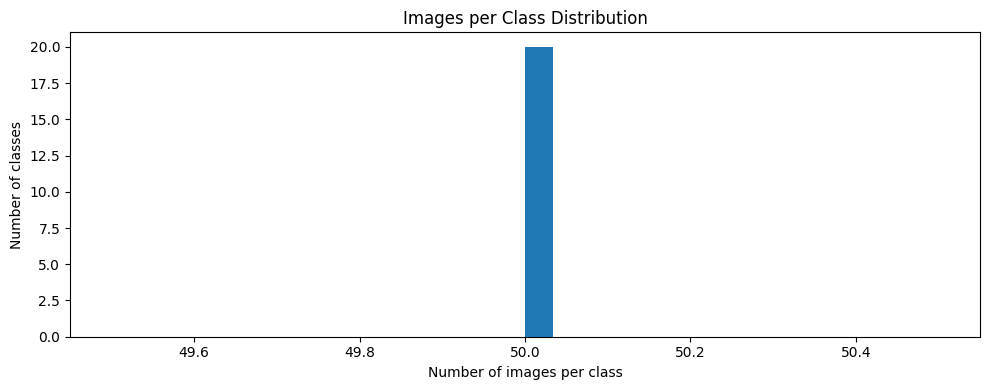

Saved figure to outputs\figures\top_frequent_classes.png


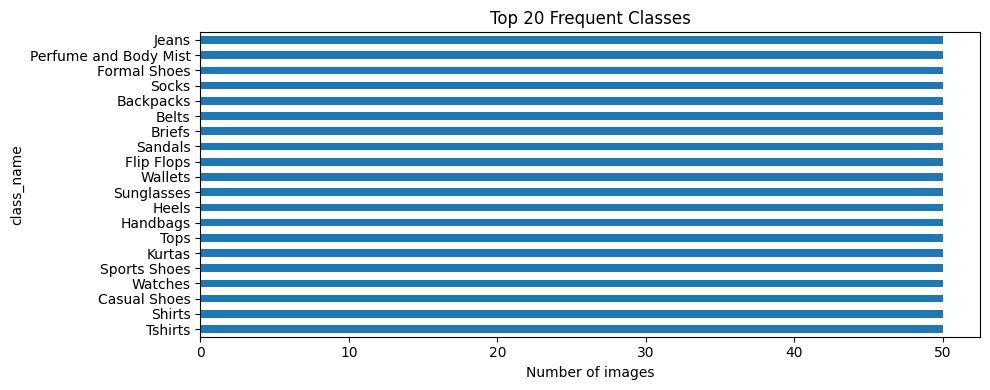

In [13]:
def save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved figure to {path}")

if not DATA_AVAILABLE:
    print("EDA skipped because no dataset images are available yet.")
    print_dataset_missing_message()
else:
    print(f"Total number of images: {len(image_index)}")
    print(f"Number of classes: {image_index['class_name'].nunique()}")
    print("\nSplit distribution:")
    display(image_index["split"].value_counts().rename_axis("split").reset_index(name="num_images"))

    class_counts = image_index["class_name"].value_counts()
    print("\nTop frequent classes:")
    display(class_counts.head(10).rename_axis("class_name").reset_index(name="num_images"))
    print("\nLow frequent classes:")
    display(class_counts.tail(10).rename_axis("class_name").reset_index(name="num_images"))

    plt.figure(figsize=(10, 4))
    class_counts.plot(kind="hist", bins=30)
    plt.title("Images per Class Distribution")
    plt.xlabel("Number of images per class")
    plt.ylabel("Number of classes")
    save_current_figure("images_per_class_distribution.png")
    plt.show()

    plt.figure(figsize=(10, 4))
    class_counts.head(20).sort_values().plot(kind="barh")
    plt.title("Top 20 Frequent Classes")
    plt.xlabel("Number of images")
    save_current_figure("top_frequent_classes.png")
    plt.show()


Saved figure to outputs\figures\random_samples.png


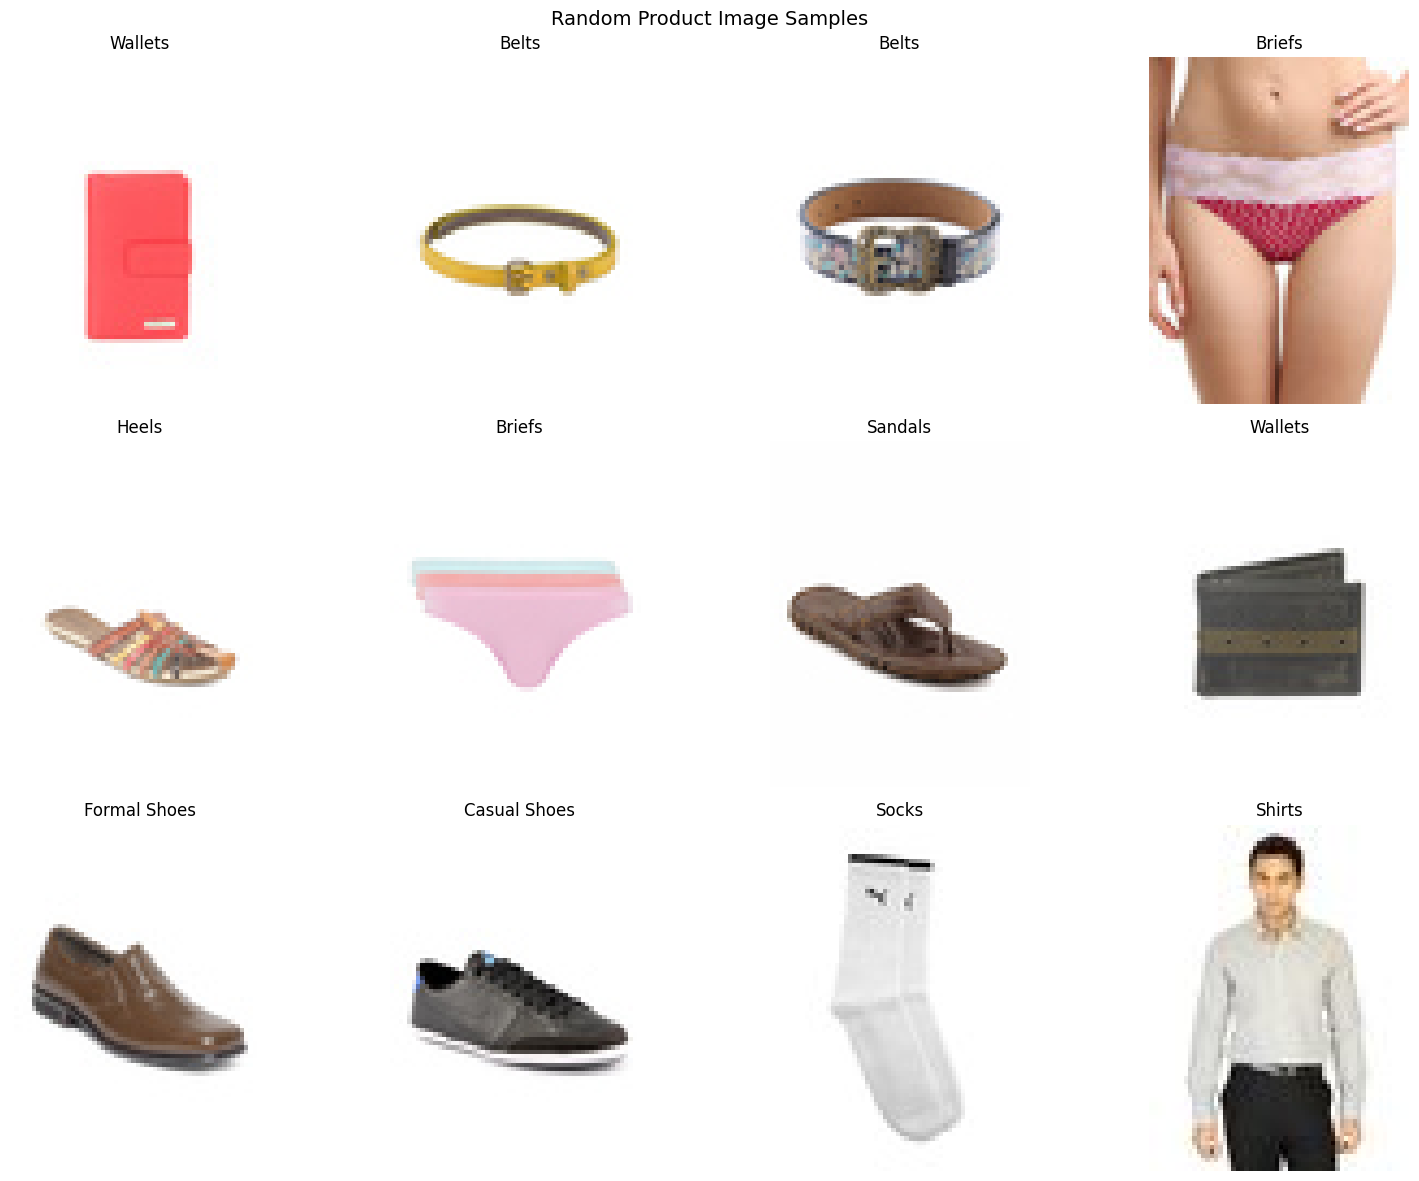

,width,height
count,500.0,500.0
mean,60.0,80.0
std,0.0,0.0
min,60.0,80.0
25%,60.0,80.0
50%,60.0,80.0
75%,60.0,80.0
max,60.0,80.0


Saved figure to outputs\figures\image_size_distribution.png


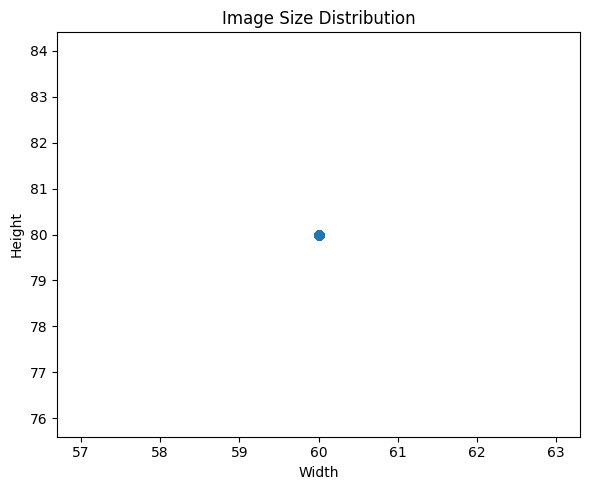

In [14]:
def show_random_samples(df, n=12, title="Random Product Image Samples", save_name="random_samples.png"):
    if df.empty:
        print("No images available for sampling.")
        return
    sample_df = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    cols = min(4, len(sample_df))
    rows = int(np.ceil(len(sample_df) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, row in sample_df.iterrows():
        plt.subplot(rows, cols, i + 1)
        try:
            img = Image.open(row["image_path"]).convert("RGB")
            plt.imshow(img)
            plt.title(str(row["class_name"])[:35])
        except Exception as exc:
            plt.text(0.5, 0.5, f"Load error\n{exc}", ha="center", va="center")
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    save_current_figure(save_name)
    plt.show()

def compute_image_size_distribution(df, max_images=500):
    sample_df = df.sample(n=min(max_images, len(df)), random_state=SEED)
    sizes = []
    for path in sample_df["image_path"]:
        try:
            with Image.open(path) as img:
                sizes.append({"width": img.width, "height": img.height})
        except Exception:
            pass
    return pd.DataFrame(sizes)

if DATA_AVAILABLE:
    show_random_samples(image_index)
    size_df = compute_image_size_distribution(image_index)
    if not size_df.empty:
        display(size_df.describe())
        plt.figure(figsize=(6, 5))
        plt.scatter(size_df["width"], size_df["height"], alpha=0.5)
        plt.title("Image Size Distribution")
        plt.xlabel("Width")
        plt.ylabel("Height")
        save_current_figure("image_size_distribution.png")
        plt.show()
else:
    print("Sample and image-size visualizations skipped because no images are available.")


# 5. Data Preprocessing and PyTorch Dataset

Images must be resized because CNNs process tensors in fixed-size batches. Normalization aligns input pixel values with the distribution expected by ImageNet-pretrained models. Batching groups multiple images into one tensor so the GPU or CPU can process them efficiently. Data augmentation can help product recognition by exposing the model to realistic appearance variation, while evaluation transforms remain deterministic for fair comparison and retrieval.


In [15]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ProductImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row["image_path"])
        label = int(row["class_id"])
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label, str(image_path)

if not DATA_AVAILABLE:
    print("Dataset and DataLoader creation skipped because image_index is empty.")
else:
    train_df = image_index[image_index["split"] == "train"].reset_index(drop=True)
    val_df = image_index[image_index["split"] == "val"].reset_index(drop=True)
    test_df = image_index[image_index["split"] == "test"].reset_index(drop=True)

    if val_df.empty and not train_df.empty:
        print("Validation split is empty. Using a small training sample as validation for debug purposes.")
        val_df = train_df.sample(n=min(max(1, len(train_df) // 10), len(train_df)), random_state=SEED).reset_index(drop=True)
    if test_df.empty:
        print("Test split is empty. Evaluation will use validation data where needed.")

    train_dataset = ProductImageDataset(train_df, transform=train_transform)
    val_dataset = ProductImageDataset(val_df, transform=eval_transform)
    test_dataset = ProductImageDataset(test_df, transform=eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    id_to_class = image_index.drop_duplicates("class_id").set_index("class_id")["class_name"].to_dict()
    num_classes = image_index["class_id"].nunique()

    print(f"Train images: {len(train_dataset)}")
    print(f"Validation images: {len(val_dataset)}")
    print(f"Test images: {len(test_dataset)}")
    print(f"Number of classes: {num_classes}")


Train images: 725
Validation images: 126
Test images: 149
Number of classes: 20


Saved figure to outputs\figures\training_batch_preview.png


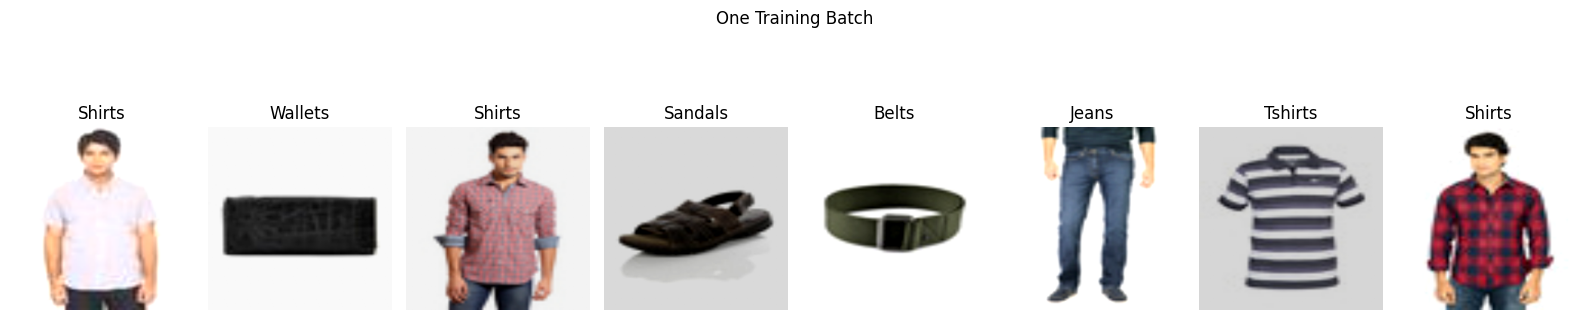

In [16]:
def denormalize_tensor(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1)

if DATA_AVAILABLE and len(train_dataset) > 0:
    images, labels, paths = next(iter(train_loader))
    show_n = min(8, images.size(0))
    plt.figure(figsize=(16, 4))
    for i in range(show_n):
        plt.subplot(1, show_n, i + 1)
        plt.imshow(denormalize_tensor(images[i]).permute(1, 2, 0))
        plt.title(id_to_class[int(labels[i])][:20])
        plt.axis("off")
    plt.suptitle("One Training Batch")
    save_current_figure("training_batch_preview.png")
    plt.show()
else:
    print("Batch preview skipped because no training data is available.")


# 6. CNN Baseline Model

ResNet is a reasonable baseline because it is a strong, widely used CNN architecture that remains simple enough for a course project. Residual connections let a network learn corrections on top of previous representations, which makes deeper models easier to optimize. ImageNet-pretrained weights are useful because early and middle CNN layers learn general visual patterns such as edges, colors, textures, and object parts. The final classification layer must be replaced because the Fashion Product Images dataset has a different class set. The feature vector before that final layer can later become the image embedding used for visual search.


In [17]:
def build_resnet_model(model_name, num_classes, pretrained=True):
    model_name = model_name.lower()
    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
    else:
        raise ValueError("MODEL_NAME must be either 'resnet18' or 'resnet50'.")

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

if not DATA_AVAILABLE:
    model = None
    print("Model creation skipped because no dataset is available yet.")
else:
    model = build_resnet_model(MODEL_NAME, num_classes=num_classes, pretrained=USE_PRETRAINED).to(DEVICE)
    print(f"Model name: {MODEL_NAME}")
    print(f"Pretrained ImageNet weights: {USE_PRETRAINED}")
    print(f"Number of classes: {num_classes}")
    print(f"Device: {DEVICE}")
    print(f"Embedding dimension before final FC: {model.fc.in_features}")


Model name: resnet18
Pretrained ImageNet weights: True
Number of classes: 20
Device: cuda
Embedding dimension before final FC: 512


# 7. Model Training

Cross-entropy loss measures how well the predicted class distribution matches the true product category. Top-1 accuracy checks whether the highest-confidence class is correct, while Top-5 accuracy checks whether the true class appears among the five most likely predictions. Top-K accuracy is useful for product recognition because visually similar products can be ambiguous, and search systems often care about a ranked candidate set rather than only one predicted label. Debug mode is used first to make sure the full pipeline runs before attempting larger-scale fashion product training. After the debug run works, `MEDIUM_MODE` can be enabled to run a controlled larger experiment with more classes and more samples per class without loading the full dataset at once.


Batch sanity check:
Image batch shape: (32, 3, 224, 224)
Label batch shape: (32,)
Logits shape: (32, 20)


Epoch 1/3 | train loss: 1.8947 | val loss: 0.9413 | val top-1: 0.8016 | val top-5: 0.9841
Saved best checkpoint to outputs\checkpoints\best_resnet18_fashion_products_debug.pt


Epoch 2/3 | train loss: 0.6307 | val loss: 0.5327 | val top-1: 0.8333 | val top-5: 1.0000
Saved best checkpoint to outputs\checkpoints\best_resnet18_fashion_products_debug.pt


Epoch 3/3 | train loss: 0.3572 | val loss: 0.4688 | val top-1: 0.8810 | val top-5: 1.0000
Saved best checkpoint to outputs\checkpoints\best_resnet18_fashion_products_debug.pt
Training time: 14.54 seconds


,epoch,train_loss,val_loss,val_top1,val_top5
0,1,1.894719,0.941297,0.801587,0.984127
1,2,0.630704,0.532730,0.833333,1.000000
2,3,0.357174,0.468834,0.880952,1.000000


Saved figure to outputs\figures\training_curves.png


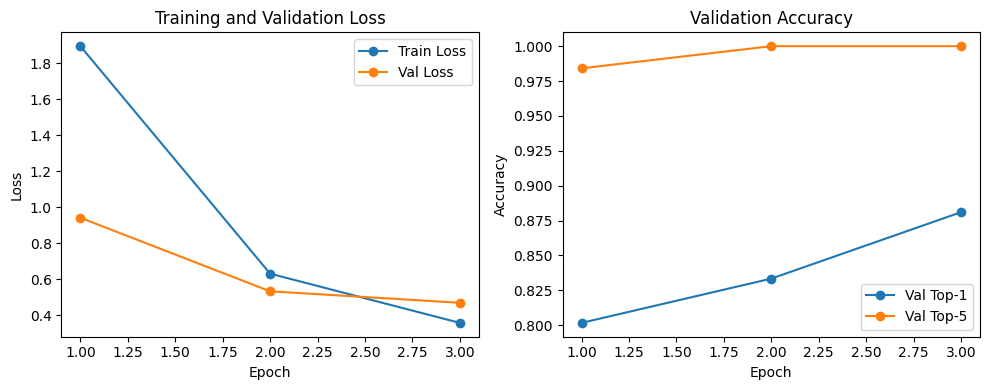

In [18]:
def topk_accuracy(logits, labels, k=5):
    k = min(k, logits.size(1))
    _, preds = logits.topk(k, dim=1)
    correct = preds.eq(labels.view(-1, 1).expand_as(preds))
    return correct.any(dim=1).float().mean().item()

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = total_top1 = total_top5 = total_samples = 0
    with torch.set_grad_enabled(is_train):
        for images, labels, _ in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_top1 += topk_accuracy(logits, labels, k=1) * batch_size
            total_top5 += topk_accuracy(logits, labels, k=5) * batch_size
            total_samples += batch_size
    if total_samples == 0:
        return {"loss": np.nan, "top1": np.nan, "top5": np.nan}
    return {"loss": total_loss / total_samples, "top1": total_top1 / total_samples, "top5": total_top5 / total_samples}

import time

history = []
best_val_top1 = -1.0
training_time_seconds = np.nan
best_checkpoint_path = CHECKPOINT_DIR / f"best_{MODEL_NAME}_fashion_products_debug.pt"

if not DATA_AVAILABLE or model is None or len(train_dataset) == 0 or len(val_dataset) == 0:
    print("Training skipped because the dataset/model is not ready.")
    print_dataset_missing_message()
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    sanity_images, sanity_labels, _ = next(iter(train_loader))
    with torch.no_grad():
        sanity_logits = model(sanity_images.to(DEVICE))
    print("Batch sanity check:")
    print(f"Image batch shape: {tuple(sanity_images.shape)}")
    print(f"Label batch shape: {tuple(sanity_labels.shape)}")
    print(f"Logits shape: {tuple(sanity_logits.shape)}")

    training_start_time = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "val_top1": val_metrics["top1"],
            "val_top5": val_metrics["top5"],
        }
        history.append(row)
        print(f"Epoch {epoch}/{EPOCHS} | train loss: {row['train_loss']:.4f} | val loss: {row['val_loss']:.4f} | val top-1: {row['val_top1']:.4f} | val top-5: {row['val_top5']:.4f}")
        if val_metrics["top1"] > best_val_top1:
            best_val_top1 = val_metrics["top1"]
            torch.save({
                "model_state_dict": model.state_dict(),
                "model_name": MODEL_NAME,
                "num_classes": num_classes,
                "id_to_class": id_to_class,
            }, best_checkpoint_path)
            print(f"Saved best checkpoint to {best_checkpoint_path}")

    training_time_seconds = time.perf_counter() - training_start_time
    print(f"Training time: {training_time_seconds:.2f} seconds")

    history_df = pd.DataFrame(history)
    display(history_df)
    history_df.to_csv(REPORT_DIR / "training_history.csv", index=False)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["val_top1"], marker="o", label="Val Top-1")
    plt.plot(history_df["epoch"], history_df["val_top5"], marker="o", label="Val Top-5")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()
    save_current_figure("training_curves.png")
    plt.show()


# 8. Model Evaluation

Evaluation should be separated from training because it gives a clearer estimate of behavior on data not used for parameter updates. Product recognition errors often come from visually similar classes, fine-grained category differences, background bias, or long-tail classes with too few examples. These errors are also meaningful for retrieval: if confused categories look similar, the retrieved results may still be useful for visual search, while weak long-tail performance suggests the need for better data or representation learning.


Evaluation split: test
Top-1 accuracy: 0.8792
Top-5 accuracy: 0.9866
Loss: 0.4566


,class_id,class_name,num_images,accuracy
3,3,Casual Shoes,6,0.166667
7,7,Heels,6,0.666667
11,11,Sandals,12,0.750000
4,4,Flip Flops,14,0.785714
17,17,Tshirts,5,0.800000
14,14,Sports Shoes,6,0.833333
6,6,Handbags,9,0.888889
8,8,Jeans,10,0.900000
16,16,Tops,10,0.900000
0,0,Backpacks,9,1.000000


Saved figure to outputs\figures\confusion_matrix.png


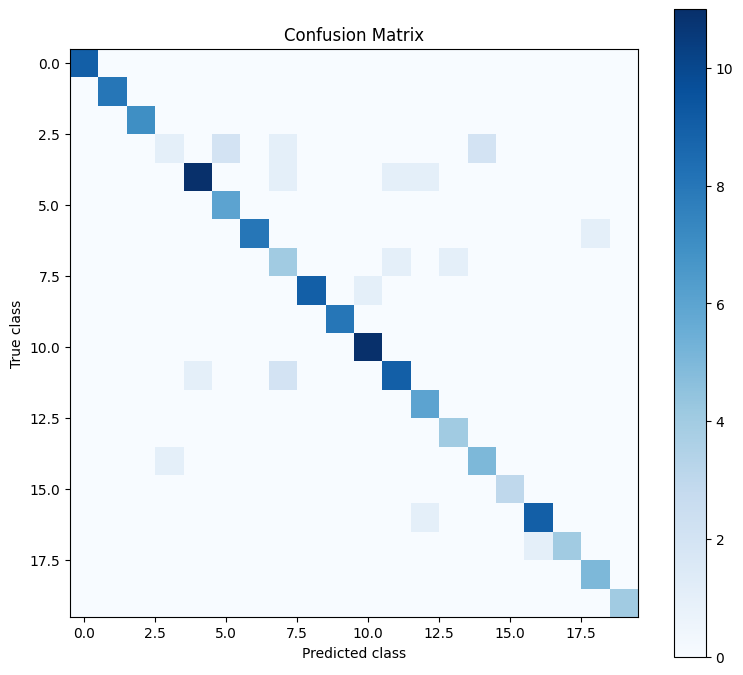

Analysis: Top-5 accuracy is often more search-oriented than Top-1 because product systems usually return ranked candidates.


In [19]:
def evaluate_model(model, loader, criterion):
    metrics = run_one_epoch(model, loader, criterion, optimizer=None)
    all_labels, all_preds = [], []
    model.eval()
    with torch.no_grad():
        for images, labels, _ in loader:
            logits = model(images.to(DEVICE))
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
    return metrics, np.array(all_labels), np.array(all_preds)

if not DATA_AVAILABLE or model is None:
    print("Evaluation skipped because no trained model/data is available.")
elif not best_checkpoint_path.exists():
    print("Best checkpoint not found. Run the training section first.")
else:
    checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)
    eval_loader = test_loader if len(test_dataset) > 0 else val_loader
    eval_name = "test" if len(test_dataset) > 0 else "validation"
    criterion = nn.CrossEntropyLoss()
    eval_metrics, y_true, y_pred = evaluate_model(model, eval_loader, criterion)

    print(f"Evaluation split: {eval_name}")
    print(f"Top-1 accuracy: {eval_metrics['top1']:.4f}")
    print(f"Top-5 accuracy: {eval_metrics['top5']:.4f}")
    print(f"Loss: {eval_metrics['loss']:.4f}")

    if len(y_true) > 0:
        per_class_rows = []
        for class_id in sorted(np.unique(y_true)):
            mask = y_true == class_id
            per_class_rows.append({
                "class_id": int(class_id),
                "class_name": id_to_class.get(int(class_id), str(class_id)),
                "num_images": int(mask.sum()),
                "accuracy": float((y_pred[mask] == y_true[mask]).mean()),
            })
        per_class_df = pd.DataFrame(per_class_rows).sort_values("accuracy")
        display(per_class_df.head(10))
        per_class_df.to_csv(REPORT_DIR / "per_class_accuracy.csv", index=False)

        if num_classes <= 50:
            cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
            plt.figure(figsize=(8, 7))
            plt.imshow(cm, cmap="Blues")
            plt.title("Confusion Matrix")
            plt.xlabel("Predicted class")
            plt.ylabel("True class")
            plt.colorbar()
            save_current_figure("confusion_matrix.png")
            plt.show()
        else:
            print("Confusion matrix skipped because there are more than 50 classes.")

    print("Analysis: Top-5 accuracy is often more search-oriented than Top-1 because product systems usually return ranked candidates.")


# 9. Embedding Extraction

An image embedding is a numerical vector that represents visual content. Embeddings are useful for visual search because query and gallery images can be compared directly in vector space. The penultimate layer of a CNN is a practical embedding source because it is trained to separate product categories while preserving rich visual patterns. By removing the final classification layer, the ResNet becomes a feature extractor, changing the project from pure classification to retrieval.


In [20]:
def build_embedding_model(classification_model):
    embedding_model = build_resnet_model(MODEL_NAME, num_classes=num_classes, pretrained=False)
    embedding_model.load_state_dict(classification_model.state_dict())
    embedding_dim = embedding_model.fc.in_features
    embedding_model.fc = nn.Identity()
    embedding_model = embedding_model.to(DEVICE)
    embedding_model.eval()
    return embedding_model, embedding_dim

def extract_embeddings(embedding_model, loader):
    all_embeddings, all_labels, all_paths = [], [], []
    embedding_model.eval()
    with torch.no_grad():
        for images, labels, paths in loader:
            embeddings = embedding_model(images.to(DEVICE))
            embeddings = nn.functional.normalize(embeddings, p=2, dim=1)
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.extend(labels.numpy().tolist())
            all_paths.extend(list(paths))
    if not all_embeddings:
        return np.empty((0, 0)), [], []
    return np.vstack(all_embeddings), all_labels, all_paths

if not DATA_AVAILABLE or model is None:
    print("Embedding extraction skipped because no trained model/data is available.")
elif not best_checkpoint_path.exists():
    print("Best checkpoint not found. Run training first.")
else:
    checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)

    embedding_model, embedding_dim = build_embedding_model(model)
    print(f"Embedding dimension: {embedding_dim}")

    gallery_df = train_df.reset_index(drop=True)
    query_df = test_df.reset_index(drop=True) if len(test_df) > 0 else val_df.reset_index(drop=True)
    gallery_dataset = ProductImageDataset(gallery_df, transform=eval_transform)
    query_dataset = ProductImageDataset(query_df, transform=eval_transform)
    gallery_loader = DataLoader(gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    query_loader = DataLoader(query_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    gallery_embeddings, gallery_labels, gallery_paths = extract_embeddings(embedding_model, gallery_loader)
    query_embeddings, query_labels, query_paths = extract_embeddings(embedding_model, query_loader)

    print(f"Gallery embedding matrix shape: {gallery_embeddings.shape}")
    print(f"Query embedding matrix shape: {query_embeddings.shape}")
    np.save(REPORT_DIR / "gallery_embeddings.npy", gallery_embeddings)
    np.save(REPORT_DIR / "query_embeddings.npy", query_embeddings)
    pd.DataFrame({"image_path": gallery_paths, "class_id": gallery_labels}).to_csv(REPORT_DIR / "gallery_embedding_index.csv", index=False)
    pd.DataFrame({"image_path": query_paths, "class_id": query_labels}).to_csv(REPORT_DIR / "query_embedding_index.csv", index=False)
    print(f"Saved embedding artifacts to {REPORT_DIR}")


Embedding dimension: 512


Gallery embedding matrix shape: (725, 512)
Query embedding matrix shape: (149, 512)
Saved embedding artifacts to outputs\reports


# 10. Visual Similarity Retrieval

Visual similarity retrieval is closer to search recall than classification because it returns a ranked list of candidate items rather than a single class label. Cosine similarity measures the angle between two embedding vectors; after normalization, higher cosine similarity means the model considers two images visually closer. Top-K retrieval returns the K nearest gallery images for a query image, simulating product visual search where a user provides an image and the system returns similar products.


Saved figure to outputs\figures\retrieval_example_1.png


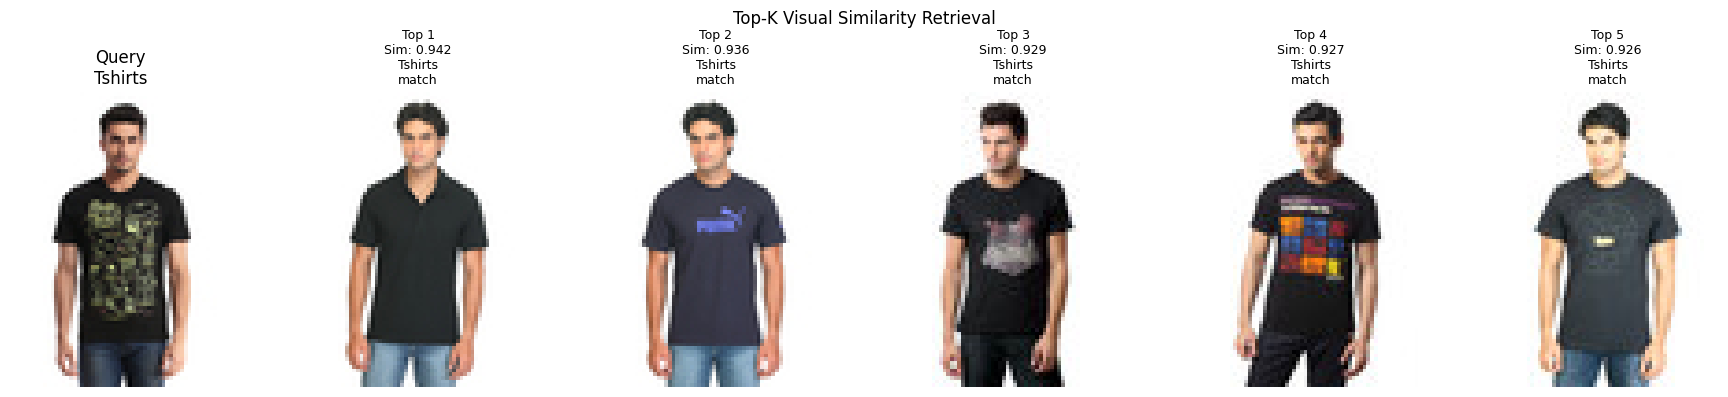

Saved figure to outputs\figures\retrieval_example_2.png


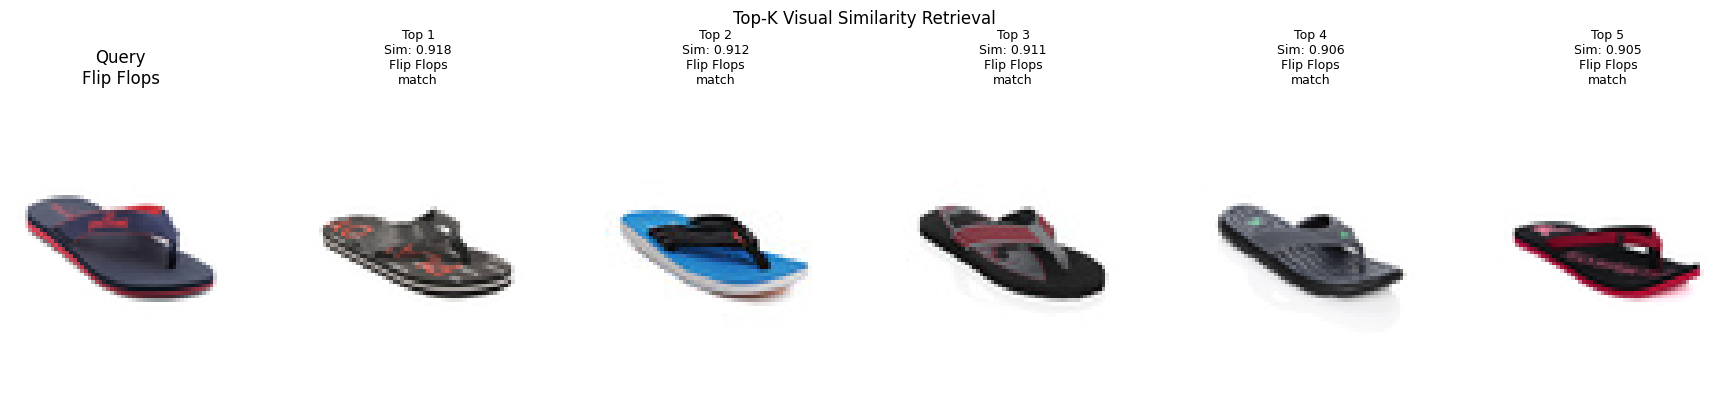

Saved figure to outputs\figures\retrieval_example_3.png


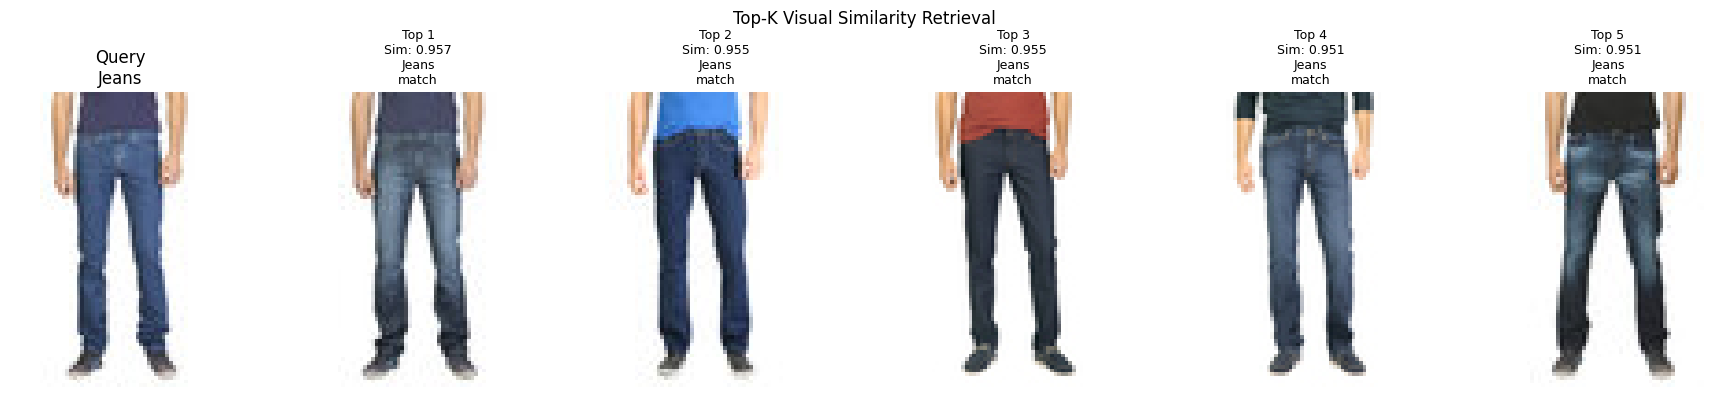

In [21]:
def fit_retrieval_index(gallery_embeddings):
    if gallery_embeddings.size == 0:
        return None
    nn_index = NearestNeighbors(metric="cosine", algorithm="brute")
    nn_index.fit(gallery_embeddings)
    return nn_index

def retrieve_top_k(nn_index, query_vector, k=5):
    distances, indices = nn_index.kneighbors(query_vector.reshape(1, -1), n_neighbors=min(k, len(gallery_embeddings)))
    similarities = 1.0 - distances[0]
    return indices[0], similarities

def plot_retrieval_result(query_path, query_label, retrieved_indices, similarities, save_name=None):
    k = len(retrieved_indices)
    plt.figure(figsize=(3 * (k + 1), 4))
    plt.subplot(1, k + 1, 1)
    plt.imshow(Image.open(query_path).convert("RGB"))
    plt.title(f"Query\n{id_to_class.get(int(query_label), query_label)}")
    plt.axis("off")
    for rank, (idx, sim) in enumerate(zip(retrieved_indices, similarities), start=1):
        retrieved_path = gallery_paths[idx]
        retrieved_label = gallery_labels[idx]
        match_text = "match" if int(retrieved_label) == int(query_label) else "different"
        plt.subplot(1, k + 1, rank + 1)
        plt.imshow(Image.open(retrieved_path).convert("RGB"))
        plt.title(f"Top {rank}\nSim: {sim:.3f}\n{id_to_class.get(int(retrieved_label), retrieved_label)}\n{match_text}", fontsize=9)
        plt.axis("off")
    plt.suptitle("Top-K Visual Similarity Retrieval")
    if save_name is not None:
        save_current_figure(save_name)
    plt.show()

if "gallery_embeddings" not in globals() or gallery_embeddings.size == 0 or "query_embeddings" not in globals() or query_embeddings.size == 0:
    print("Retrieval skipped because embeddings are not available. Run embedding extraction first.")
else:
    TOP_K = 5
    nn_index = fit_retrieval_index(gallery_embeddings)
    example_count = min(3, len(query_embeddings))
    example_indices = np.linspace(0, len(query_embeddings) - 1, num=example_count, dtype=int)
    for example_num, query_idx in enumerate(example_indices, start=1):
        retrieved_indices, similarities = retrieve_top_k(nn_index, query_embeddings[query_idx], k=TOP_K)
        plot_retrieval_result(query_paths[query_idx], query_labels[query_idx], retrieved_indices, similarities, save_name=f"retrieval_example_{example_num}.png")


# 11. Retrieval Evaluation

Recall@K measures whether at least one relevant item appears in the top K retrieved results. Here, an item is treated as relevant if it has the same class label as the query image. Recall@1 is strict, while Recall@5 and Recall@10 are closer to practical search behavior because users often inspect several results. Recall@K is important because first-stage retrieval must find good candidates before any ranking model can reorder them. Mean Average Precision (mAP) is also useful because it rewards placing all relevant items early in the ranking, but it is left as future work to keep this notebook readable.


In [22]:
def recall_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k=5):
    if len(query_embeddings) == 0 or len(gallery_embeddings) == 0:
        return np.nan
    nn_index = fit_retrieval_index(gallery_embeddings)
    hits = 0
    for query_vector, query_label in zip(query_embeddings, query_labels):
        retrieved_indices, _ = retrieve_top_k(nn_index, query_vector, k=k)
        retrieved_labels = [gallery_labels[idx] for idx in retrieved_indices]
        if int(query_label) in [int(label) for label in retrieved_labels]:
            hits += 1
    return hits / len(query_embeddings)

if "gallery_embeddings" not in globals() or gallery_embeddings.size == 0 or "query_embeddings" not in globals() or query_embeddings.size == 0:
    print("Retrieval evaluation skipped because embeddings are not available.")
else:
    retrieval_metrics = {
        "Recall@1": recall_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k=1),
        "Recall@5": recall_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k=5),
        "Recall@10": recall_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k=10),
    }
    retrieval_df = pd.DataFrame([retrieval_metrics])
    display(retrieval_df)
    retrieval_df.to_csv(REPORT_DIR / "retrieval_metrics.csv", index=False)
    print("Analysis: Higher Recall@K means the embedding space is more useful for visual search because relevant products are retrieved within the top candidates.")


,Recall@1,Recall@5,Recall@10
0,0.892617,0.95302,0.973154


Analysis: Higher Recall@K means the embedding space is more useful for visual search because relevant products are retrieved within the top candidates.


In [23]:
def current_samples_per_class():
    if DEBUG_MODE:
        return DEBUG_MAX_IMAGES_PER_CLASS
    if MEDIUM_MODE:
        return MEDIUM_MAX_IMAGES_PER_CLASS
    return "full"


def current_experiment_mode():
    if DEBUG_MODE:
        return "debug"
    if MEDIUM_MODE:
        return "medium"
    return "full"


summary_path = REPORT_DIR / "experiment_summary.csv"

if not DATA_AVAILABLE:
    print("Experiment summary skipped because data is not available.")
elif "eval_metrics" not in globals() or "retrieval_metrics" not in globals():
    print("Experiment summary skipped because evaluation or retrieval metrics are not available yet.")
else:
    experiment_row = {
        "experiment_mode": current_experiment_mode(),
        "model_name": MODEL_NAME,
        "num_classes": int(num_classes),
        "samples_per_class": current_samples_per_class(),
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "test_size": int(len(test_df)),
        "top1_acc": float(eval_metrics.get("top1", np.nan)),
        "top5_acc": float(eval_metrics.get("top5", np.nan)),
        "recall@1": float(retrieval_metrics.get("Recall@1", np.nan)),
        "recall@5": float(retrieval_metrics.get("Recall@5", np.nan)),
        "recall@10": float(retrieval_metrics.get("Recall@10", np.nan)),
        "training_time": float(training_time_seconds) if not pd.isna(training_time_seconds) else np.nan,
    }

    experiment_summary_df = pd.DataFrame([experiment_row])
    if summary_path.exists():
        previous_summary_df = pd.read_csv(summary_path)
        experiment_summary_df = pd.concat([previous_summary_df, experiment_summary_df], ignore_index=True)
        experiment_summary_df = experiment_summary_df.drop_duplicates(
            subset=["experiment_mode", "model_name", "num_classes", "samples_per_class", "train_size", "val_size", "test_size"],
            keep="last",
        )

    experiment_summary_df.to_csv(summary_path, index=False)
    display(experiment_summary_df)
    print(f"Saved experiment summary to {summary_path}")


,experiment_mode,model_name,num_classes,samples_per_class,train_size,val_size,test_size,top1_acc,top5_acc,recall@1,recall@5,recall@10,training_time,embedding_extraction_time_seconds,embedding_dim,checkpoint_source
0,debug,resnet18,20,50,725,126.0,149,0.879195,0.986577,0.879195,0.946309,0.973154,18.684527,NaN,NaN,NaN
1,debug,clip_vit_b_32_openai_local,20,50,725,126.0,149,NaN,NaN,0.879195,0.966443,0.986577,0.000000,11.547331,512.0,models/huggingface/timm_vit_base_patch32_clip_...
2,full,resnet18_full_dataset,132,all,31070,6666.0,6669,0.885140,0.989204,0.899085,0.935073,0.946619,NaN,NaN,512.0,outputs/checkpoints/resnet18_full_best.pth
3,full,clip_vit_b_32_openai_full,132,all,31070,NaN,6669,NaN,NaN,0.828310,0.954116,0.972410,0.000000,28.259619,512.0,models/huggingface/timm_vit_base_patch32_clip_...
4,debug,resnet18,20,50,725,126.0,149,0.879195,0.986577,0.892617,0.953020,0.973154,14.535509,NaN,NaN,NaN


Saved experiment summary to outputs\reports\experiment_summary.csv


# 12. Business Interpretation

This project can be mapped to TikTok Search, e-commerce search, and broader content understanding systems. In a short-video platform, product objects may appear inside user-generated content, livestreams, or shopping videos. A visual recognition model can identify the likely product category, while an embedding retrieval model can connect the visual content to similar catalog items. This supports search, shopping recommendations, duplicate detection, and visual content organization.

Product visual embeddings are especially useful because they preserve similarity information that is lost in a single classification label. A classifier may predict "sneaker" or "bag," but a search system needs to rank many visually related items. Embeddings allow a system to retrieve products with similar color, shape, style, texture, and layout. This is closer to how users search visually: they may not know the exact product name, but they can provide or interact with an image that expresses their intent.

Image classification alone is insufficient for search because it produces a closed-set decision. Real product catalogs are dynamic, long-tailed, and fine-grained. New products appear frequently, many products have only a few examples, and visually similar items may belong to different product IDs. A retrieval system can handle this more flexibly by indexing embeddings for newly added images without retraining the entire classifier every time.

Long-tail classes remain challenging because rare categories provide fewer examples for representation learning. Retrieval failure cases are valuable diagnostic signals. If the retrieved items share background rather than product identity, the model may need stronger cropping, object localization, or augmentation. If visually similar classes are confused, this may suggest finer-grained labels, metric learning, or multimodal signals.

This baseline could be upgraded with ViT or Swin Transformer backbones, CLIP-style image-text retrieval using titles and descriptions, FAISS vector indexing for millions of products, and multimodal ranking that combines visual embeddings with text relevance, metadata, and user behavior.


# 13. Conclusion and Future Work

This notebook implemented a complete course-level pipeline for product visual search and recognition. It prepared the Fashion Product Images Small dataset, performed exploratory data analysis, built a ResNet baseline classifier, trained and evaluated the model, extracted image embeddings from the trained CNN, and used cosine nearest-neighbor search to retrieve visually similar product images.

The main lesson is that product recognition and product search are connected but not identical. Classification provides supervised learning signals and category-level evaluation, while embeddings make the system useful for retrieval, recommendation, and content understanding. The debug-first design helps verify the full workflow before scaling to more classes and more images.

What worked well is the simplicity and interpretability of the pipeline: ResNet provides a strong baseline, the penultimate layer gives useful embeddings, and Top-K retrieval makes the result easy to visualize. Remaining limitations include the small debug subset, the fact that classification training does not directly optimize retrieval, long-tail class difficulty, and brute-force nearest-neighbor search scalability.

Future extensions include larger-scale training, stronger but realistic data augmentation, ViT or Swin Transformer backbones, CLIP-style image-text retrieval, FAISS for scalable retrieval, better long-tail class handling, metric learning losses, object detection or cropping before embedding extraction, and deployment as a small visual search demo.


# 14. Experiment Summary and Business Interpretation

The debug subset is used first because visual search projects have several moving parts: dataset scanning, label mapping, image preprocessing, CNN training, embedding extraction, nearest-neighbor retrieval, and retrieval evaluation. A small subset makes it possible to validate the whole pipeline quickly before spending time on a larger experiment. Once the debug run is stable, the notebook provides `MEDIUM_MODE`, which increases the number of classes and samples per class while still avoiding the cost and risk of loading the entire dataset at once.

Top-1 accuracy measures whether the model's single highest-confidence prediction matches the true product type. Top-5 accuracy measures whether the correct product type appears among the five most likely predictions. For product recognition, Top-5 is often business-relevant because visually similar fashion items can be ambiguous, and downstream search systems usually consume a candidate set rather than one hard label.

Recall@K is the key retrieval-side metric in this notebook. Recall@1 asks whether the first retrieved product has the same product type as the query. Recall@5 and Recall@10 ask whether at least one relevant item appears in the first few results. In a visual search or recommendation system, high Recall@K means the embedding model can recover useful candidate products for later ranking, filtering, or user-facing display.

Duplicate images can create train/test leakage when the same image appears in both the gallery and evaluation side of the pipeline. Leakage makes the model and retrieval system look better than they really are because the system may retrieve an exact duplicate rather than generalizing to a visually similar unseen product. This notebook therefore prefers the canonical `data/raw/images/` folder when duplicate extracted folders are present.

ResNet18 is a practical baseline because it is fast, stable, widely available in `torchvision`, and strong enough to learn meaningful product representations from a moderate dataset. It is not the final state of the art, but it creates a reliable reference point for future upgrades such as ResNet50, ViT, Swin Transformer, CLIP-style image-text retrieval, or FAISS-based large-scale vector search.


# FINAL SUBMISSION SECTION: CLIP DEBUG RETRIEVAL IMPLEMENTATION DETAILS

The earlier notebook cells show the executed ResNet18 debug pipeline, including supervised training, evaluation, embedding extraction, visual retrieval, and Recall@K evaluation. To avoid rerunning the full notebook after that experiment completed, the CLIP comparison was executed separately with the same debug subset and then embedded here as code and captured output.

This section is included so the submitted `.ipynb` is self-contained: it shows how CLIP was loaded from a local checkpoint, how the same debug data split was reconstructed, how CLIP image embeddings were extracted, how cosine retrieval was evaluated, and how the final ResNet18-vs-CLIP comparison was produced.

Safety note: the code below is included as implementation evidence. It should not be re-run unless the user intentionally wants to reproduce CLIP debug retrieval. It does not train ResNet18 and it does not process the full 44,441 images as embeddings; it uses the 1,000-image debug subset.


In [24]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.neighbors import NearestNeighbors
import open_clip

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
DATA_RAW_DIR = Path("data/raw")
REPORT_DIR = Path("outputs/reports")
FIGURE_DIR = Path("outputs/figures")
CLIP_EXAMPLE_DIR = FIGURE_DIR / "clip_retrieval_examples"
LOCAL_CHECKPOINT = Path("models/huggingface/timm_vit_base_patch32_clip_224_openai/open_clip_model.safetensors")

DEBUG_MODE = True
MEDIUM_MODE = False
DEBUG_NUM_CLASSES = 20
DEBUG_MAX_IMAGES_PER_CLASS = 50
BATCH_SIZE = 32
NUM_WORKERS = 0
CLIP_MODEL_NAME = "ViT-B-32"
CLIP_MODEL_ROW_NAME = "clip_vit_b_32_openai_local"
TOP_K = 5
NUM_EXAMPLES_TO_SAVE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"device={DEVICE}")
print(f"local_checkpoint={LOCAL_CHECKPOINT}")
print(f"checkpoint_exists={LOCAL_CHECKPOINT.exists()}")
print("download_new_model=False")


device=cuda
local_checkpoint=models\huggingface\timm_vit_base_patch32_clip_224_openai\open_clip_model.safetensors
checkpoint_exists=True
download_new_model=False


In [25]:
# Reconstruct the same debug subset logic used by the notebook.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
LABEL_COLUMN_PRIORITY = ["articleType", "subCategory", "masterCategory", "gender"]

def assign_splits_per_class(df, seed=SEED):
    rng = np.random.default_rng(seed)
    split_series = pd.Series(index=df.index, dtype="object")
    for _, group in df.groupby("class_name"):
        indices = group.index.to_list()
        rng.shuffle(indices)
        n = len(indices)
        if n == 1:
            assignments = ["train"]
        elif n == 2:
            assignments = ["train", "test"]
        else:
            n_train = max(1, int(round(n * 0.70)))
            n_val = max(1, int(round(n * 0.15)))
            if n_train + n_val >= n:
                n_train = max(1, n - 2)
                n_val = 1
            n_test = n - n_train - n_val
            assignments = ["train"] * n_train + ["val"] * n_val + ["test"] * n_test
        for idx, split in zip(indices, assignments):
            split_series.loc[idx] = split
    return split_series

def scan_clip_debug_index():
    styles_df = pd.read_csv(DATA_RAW_DIR / "styles.csv", on_bad_lines="skip")
    label_column = "articleType"
    styles_df["image_id"] = styles_df["id"].astype(str)
    metadata_map = styles_df.set_index("image_id")[label_column].fillna("unknown").astype(str).to_dict()

    image_paths = sorted(
        p for p in (DATA_RAW_DIR / "images").rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )
    rows = []
    for image_path in image_paths:
        rows.append({
            "image_path": str(image_path),
            "class_name": metadata_map.get(image_path.stem, "unknown"),
            "split": None,
        })
    df = pd.DataFrame(rows)
    df["split"] = assign_splits_per_class(df)

    selected_classes = df["class_name"].value_counts().head(DEBUG_NUM_CLASSES).index.tolist()
    debug_df = pd.concat([
        df[df["class_name"] == class_name].sample(
            n=min(len(df[df["class_name"] == class_name]), DEBUG_MAX_IMAGES_PER_CLASS),
            random_state=SEED,
        )
        for class_name in selected_classes
    ], ignore_index=True)

    class_to_id = {name: idx for idx, name in enumerate(sorted(debug_df["class_name"].unique()))}
    debug_df["class_id"] = debug_df["class_name"].map(class_to_id).astype(int)
    id_to_class = {idx: name for name, idx in class_to_id.items()}
    return debug_df[["image_path", "class_id", "class_name", "split"]], id_to_class

clip_image_index, clip_id_to_class = scan_clip_debug_index()
clip_train_df = clip_image_index[clip_image_index["split"] == "train"].reset_index(drop=True)
clip_val_df = clip_image_index[clip_image_index["split"] == "val"].reset_index(drop=True)
clip_test_df = clip_image_index[clip_image_index["split"] == "test"].reset_index(drop=True)
clip_query_df = clip_test_df if len(clip_test_df) > 0 else clip_val_df

print(f"debug_images={len(clip_image_index)}")
print(f"num_classes={clip_image_index['class_name'].nunique()}")
print(f"train_size={len(clip_train_df)}")
print(f"val_size={len(clip_val_df)}")
print(f"test_size={len(clip_test_df)}")


debug_images=1000
num_classes=20
train_size=725
val_size=126
test_size=149


In [26]:
class CLIPImageDataset(Dataset):
    def __init__(self, dataframe, preprocess):
        self.df = dataframe.reset_index(drop=True).copy()
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        return self.preprocess(image), int(row["class_id"]), str(image_path)

def extract_clip_embeddings(model, loader):
    embeddings, labels, paths = [], [], []
    model.eval()
    with torch.no_grad():
        for images, batch_labels, batch_paths in loader:
            features = model.encode_image(images.to(DEVICE))
            features = nn.functional.normalize(features, p=2, dim=1)
            embeddings.append(features.cpu().numpy())
            labels.extend(batch_labels.numpy().tolist())
            paths.extend(list(batch_paths))
    return np.vstack(embeddings), labels, paths

start = time.perf_counter()
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME,
    pretrained=str(LOCAL_CHECKPOINT),
    device=DEVICE,
)
clip_model = clip_model.to(DEVICE)

clip_gallery_loader = DataLoader(
    CLIPImageDataset(clip_train_df, clip_preprocess),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
clip_query_loader = DataLoader(
    CLIPImageDataset(clip_query_df, clip_preprocess),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

clip_gallery_embeddings, clip_gallery_labels, clip_gallery_paths = extract_clip_embeddings(clip_model, clip_gallery_loader)
clip_query_embeddings, clip_query_labels, clip_query_paths = extract_clip_embeddings(clip_model, clip_query_loader)
clip_runtime_seconds = time.perf_counter() - start

print(f"gallery_embedding_shape={clip_gallery_embeddings.shape}")
print(f"query_embedding_shape={clip_query_embeddings.shape}")
print(f"runtime_seconds={clip_runtime_seconds:.2f}")


gallery_embedding_shape=(725, 512)
query_embedding_shape=(149, 512)
runtime_seconds=5.38


In [27]:
def fit_retrieval_index(gallery_embeddings):
    index = NearestNeighbors(metric="cosine", algorithm="brute")
    index.fit(gallery_embeddings)
    return index

def retrieve_top_k(index, query_vector, gallery_size, k):
    distances, indices = index.kneighbors(query_vector.reshape(1, -1), n_neighbors=min(k, gallery_size))
    return indices[0], 1.0 - distances[0]

def recall_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k):
    index = fit_retrieval_index(gallery_embeddings)
    hits = 0
    for query_vector, query_label in zip(query_embeddings, query_labels):
        indices, _ = retrieve_top_k(index, query_vector, len(gallery_embeddings), k)
        retrieved_labels = [gallery_labels[idx] for idx in indices]
        if int(query_label) in [int(label) for label in retrieved_labels]:
            hits += 1
    return hits / len(query_embeddings)

clip_recall1 = recall_at_k(clip_query_embeddings, clip_query_labels, clip_gallery_embeddings, clip_gallery_labels, k=1)
clip_recall5 = recall_at_k(clip_query_embeddings, clip_query_labels, clip_gallery_embeddings, clip_gallery_labels, k=5)
clip_recall10 = recall_at_k(clip_query_embeddings, clip_query_labels, clip_gallery_embeddings, clip_gallery_labels, k=10)

print(f"recall@1={clip_recall1:.6f}")
print(f"recall@5={clip_recall5:.6f}")
print(f"recall@10={clip_recall10:.6f}")


recall@1=0.879195
recall@5=0.966443
recall@10=0.986577


In [28]:
# Final comparison table for the two debug retrieval experiments.
resnet_metrics = retrieval_metrics if "retrieval_metrics" in globals() else {}
final_results_table = pd.DataFrame([
    {
        "model": "ResNet18 supervised debug",
        "Recall@1": float(resnet_metrics.get("Recall@1", np.nan)),
        "Recall@5": float(resnet_metrics.get("Recall@5", np.nan)),
        "Recall@10": float(resnet_metrics.get("Recall@10", np.nan)),
    },
    {
        "model": "CLIP ViT-B/32 local checkpoint debug",
        "Recall@1": float(clip_recall1),
        "Recall@5": float(clip_recall5),
        "Recall@10": float(clip_recall10),
    },
])
display(final_results_table)


,model,Recall@1,Recall@5,Recall@10
0,ResNet18 supervised debug,0.892617,0.953020,0.973154
1,CLIP ViT-B/32 local checkpoint debug,0.879195,0.966443,0.986577


Saved figure to outputs\figures\model_recall_comparison.png


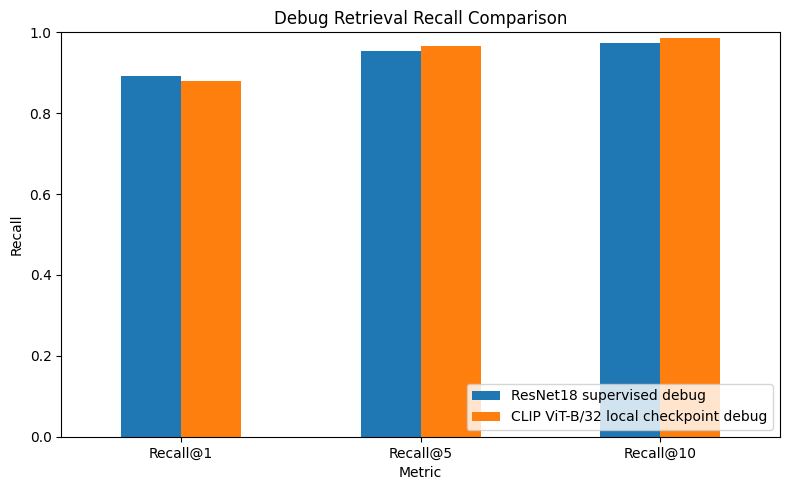

In [29]:
# Final Recall@K comparison figure embedded for single-file submission.
metric_columns = ["Recall@1", "Recall@5", "Recall@10"]
ax = final_results_table.set_index("model")[metric_columns].T.plot(
    kind="bar",
    figsize=(8, 5),
    ylim=(0, 1),
)
ax.set_title("Debug Retrieval Recall Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Recall")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
model_recall_comparison = ax.get_figure()
save_current_figure("model_recall_comparison.png")
plt.show()


## Final Conclusion

The project successfully demonstrates an end-to-end product visual search pipeline. ResNet18 validates the supervised product recognition baseline by learning category-specific embeddings from the debug subset. CLIP ViT-B/32 demonstrates that pretrained vision-language models can provide strong retrieval embeddings without dataset-specific training. On the same debug split, CLIP improves Recall@5 and Recall@10 compared with ResNet18, which supports the feasibility of product visual search for e-commerce retrieval, similar-item recommendation, and content understanding.

The main limitation is scale: this is a debug experiment, not a full production benchmark. Future work should run medium-scale evaluation, fine-tune CLIP, test more product categories, use more fine-grained labels, and add FAISS for scalable vector search.


# Full Dataset ResNet18 Experiment Summary

This section summarizes the full-dataset ResNet18 experiment. The full training loop was executed through standalone scripts rather than inside the notebook, so the notebook remains a report artifact instead of a long-running training environment. All metrics below are loaded from actual result files produced by training, evaluation, indexing, and retrieval scripts.

## Full Dataset Split Statistics

- Valid images after metadata/image filtering: **44,405**
- Number of `articleType` classes after rare-class filtering: **132**
- Train split: **31070** images
- Validation split: **6666** images
- Test/query split: **6669** images
- Dropped rare classes: **10**
- Label used for supervision and retrieval relevance: **articleType**
- Canonical image directory: `data/raw/images/`

The duplicate extracted path `data/raw/myntradataset/images/` is not used as the primary image source. This avoids duplicate images appearing across train and test splits, which would cause train/test leakage and overestimate visual retrieval performance.

## Full ResNet18 Training Setup

- Model: **ResNet18**
- Initialization: **ImageNet pretrained weights**
- Number of output classes: **132**
- Image size: **224**
- Batch size: **64**
- Optimizer: **AdamW**
- Learning rate: **0.0001**
- Weight decay: **0.0001**
- Epochs requested: **10**
- Device: **CUDA/GPU was used during training**
- Mixed precision: **enabled when CUDA was available**
- Smoke test flag in formal checkpoint: **False**

## Training Process Summary

- Best epoch by validation Top-1 accuracy: **10**
- Best validation Top-1 accuracy: **0.8843**
- Validation Top-5 accuracy at best epoch: **0.9880**
- Total epoch time from training log: **838.35 seconds**
- Best checkpoint: `outputs/checkpoints/resnet18_full_best.pth`
- Last checkpoint: `outputs/checkpoints/resnet18_full_last.pth`

![ResNet18 full training curves](outputs/figures/resnet18_full_training_curves.png)

## Full Test Classification Results

- Test loss: **0.4571**
- Test Top-1 accuracy: **0.8851**
- Test Top-5 accuracy: **0.9892**
- Test size: **6669**

These classification metrics evaluate whether the supervised ResNet18 model predicts the correct `articleType`. They are useful for product recognition, but retrieval quality is better measured through Recall@K.

## Full Retrieval Results

- Gallery split: **train**
- Gallery size: **31070**
- Query split: **test**
- Query size: **6669**
- Embedding dimension: **512**
- Recall@1: **0.8991**
- Recall@5: **0.9351**
- Recall@10: **0.9466**
- Index path: `outputs/indexes/resnet18_full_gallery_index.npz`

![ResNet18 full retrieval summary](outputs/figures/resnet18_full_retrieval_summary.png)

## ResNet18 Debug vs CLIP Debug vs ResNet18 Full Dataset

| Model | Classes | Train/Gallery Size | Test/Query Size | Top-1 Acc | Top-5 Acc | Recall@1 | Recall@5 | Recall@10 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| ResNet18 debug | 20 | 725 | 149 | 0.8792 | 0.9866 | 0.8792 | 0.9463 | 0.9732 |
| CLIP debug | 20 | 725 | 149 | nan | nan | 0.8792 | 0.9664 | 0.9866 |
| CLIP full dataset | 132 | 31070 | 6669 | nan | nan | 0.8283 | 0.9541 | 0.9724 |
| ResNet18 full dataset | 132 | 31070 | 6669 | 0.8851 | 0.9892 | 0.8991 | 0.9351 | 0.9466 |

![Model recall comparison with full ResNet18](outputs/figures/model_recall_comparison_full.png)

This comparison separates debug-scope and full-scope experiments. The CLIP full dataset row and ResNet18 full dataset row now use the same full split: train images form the gallery and test images form the query set. This makes the Streamlit model switch easier to interpret because a random sample query has the same split role for both models.

## Streamlit Product Demo Integration

The Streamlit app now supports model switching between `CLIP ViT-B/32` and `ResNet18 Full Dataset`. Users can upload a product image or choose a random sample query, select Top-K, and retrieve visually similar products. Both models now use the shared full test split for random sample queries. CLIP uses `outputs/indexes/clip_full_gallery_index.npz`, and ResNet18 Full Dataset uses `outputs/checkpoints/resnet18_full_best.pth` plus `outputs/indexes/resnet18_full_gallery_index.npz`.

## Discussion

The full ResNet18 model learns dataset-specific `articleType` boundaries from the full product image dataset. This makes it a stronger supervised baseline than the debug model and allows the Streamlit demo to search a much larger gallery. CLIP remains important because it provides general pretrained visual-semantic features without local supervised training. For visual search, Recall@K is more important than a single classification prediction because users expect a ranked set of similar products rather than only one category label.

## Limitations and Future Work

The current retrieval relevance definition is category-level `articleType`, not exact SKU-level similarity. CLIP currently uses the debug gallery unless a full CLIP index is built later. The project does not yet use FAISS, product metadata ranking, price/brand/color features, or production deployment infrastructure. Future work should build a full CLIP index, add FAISS approximate nearest-neighbor search, fine-tune CLIP on product data, incorporate product metadata, deploy with FastAPI and React, and collect user feedback for ranking improvements.


# Supervised Vision Transformer Baseline

This section adds a third baseline to the product visual search project: a supervised Vision Transformer, or ViT-B/16. The goal is to make the model comparison more precise.

The project now contains three conceptually different baselines:

| Model | Architecture | Training strategy | Pretraining source | Fine-tuned locally? | Embedding type |
|---|---|---|---|---|---|
| ResNet18 supervised | CNN | Supervised articleType classification | ImageNet | Yes | Penultimate CNN feature |
| ViT-B/16 supervised | Vision Transformer | Supervised articleType classification | ImageNet | Yes | CLS token feature |
| CLIP ViT-B/32 frozen | Vision Transformer | Image-text contrastive pretraining | Large-scale image-text pairs | No | CLIP image embedding |

This design separates two important questions. ResNet18 supervised vs ViT supervised mainly compares CNN and Transformer architecture under the same local supervision. ViT supervised vs CLIP frozen mainly compares local supervised fine-tuning with large-scale contrastive image-text pretraining.

## How to Run the ViT Baseline

The ViT implementation is now available directly in this notebook through inline functions. In the runner cell near the top, set:

```python
RUN_VIT_SUPERVISED_PIPELINE = True
VIT_SMOKE_TEST = True
```

For the formal baseline, use:

```python
RUN_VIT_SUPERVISED_PIPELINE = True
VIT_SMOKE_TEST = False
```

The notebook writes portable outputs under `outputs/`, including classification metrics, retrieval metrics, checkpoints, and gallery indexes.

In [30]:
from pathlib import Path
import json
import pandas as pd

vit_cls_path = Path("outputs/reports/vit_supervised_classification_metrics.json")
vit_ret_path = Path("outputs/reports/vit_supervised_retrieval_metrics.json")
summary_path = Path("outputs/reports/experiment_summary.csv")

if vit_cls_path.exists():
    print("ViT classification metrics:")
    print(json.dumps(json.loads(vit_cls_path.read_text(encoding="utf-8")), indent=2))
else:
    print("ViT classification metrics are not available yet. Run the inline ViT pipeline above first.")

if vit_ret_path.exists():
    print("ViT retrieval metrics:")
    print(json.dumps(json.loads(vit_ret_path.read_text(encoding="utf-8")), indent=2))
else:
    print("ViT retrieval metrics are not available yet. Run the inline ViT pipeline above first.")

if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display_cols = ["model_name", "num_classes", "train_size", "test_size", "top1_acc", "top5_acc", "recall@1", "recall@5", "recall@10"]
    available_cols = [col for col in display_cols if col in summary_df.columns]
    display(summary_df[available_cols])

ViT classification metrics are not available yet. Run the inline ViT pipeline above first.
ViT retrieval metrics are not available yet. Run the inline ViT pipeline above first.


,model_name,num_classes,train_size,test_size,top1_acc,top5_acc,recall@1,recall@5,recall@10
0,resnet18,20,725,149,0.879195,0.986577,0.879195,0.946309,0.973154
1,clip_vit_b_32_openai_local,20,725,149,NaN,NaN,0.879195,0.966443,0.986577
2,resnet18_full_dataset,132,31070,6669,0.885140,0.989204,0.899085,0.935073,0.946619
3,clip_vit_b_32_openai_full,132,31070,6669,NaN,NaN,0.828310,0.954116,0.972410
4,resnet18,20,725,149,0.879195,0.986577,0.892617,0.953020,0.973154
